In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [12]:
import pandas as pd
import geopandas as gpd

base_path = "../전체 데이터셋(수정금지)"

grid = gpd.read_file(f"{base_path}/02._격자_(하남교산).geojson")
res_pop = pd.read_csv(f"{base_path}/03._성연령별_거주인구(격자).csv")
work_pop = pd.read_csv("../전처리된 데이터셋/05._시간대별_직장인구_전처리.csv")
visit_pop = pd.read_csv("../전처리된 데이터셋/06._시간대별_방문인구_전처리.csv")
road = gpd.read_file(f"{base_path}/08.상세도로망_네트워크.geojson")
speed = pd.read_csv(f"{base_path}/09._평균속도.csv")
traffic = pd.read_csv(f"{base_path}/10._추정교통량.csv")
cong_freq = pd.read_csv(f"{base_path}/11._혼잡빈도강도.csv")
cong_time = pd.read_csv(f"{base_path}/12._혼잡시간강도.csv")
accident = gpd.read_file(f"{base_path}/13._교통사고이력.geojson")
school_zone = pd.read_csv("../전처리된 데이터셋/14._어린이보호구역_revised.csv")
school = pd.read_csv(f"{base_path}/15._학교현황.csv")
kindergarten = pd.read_csv("../전처리된 데이터셋/16._유치원현황_revised.csv")
daycare = pd.read_csv("../전처리된 데이터셋/17._어린이집현황_revised.csv")
crosswalk = pd.read_csv(f"{base_path}/18._횡단보도_위치정보.csv")
bus_stop = pd.read_csv(f"{base_path}/19._버스정류장_위치정보.csv")
cctv = pd.read_csv("../전처리된 데이터셋/20._CCTV_현황_revised.csv")
speed_bump = pd.read_csv("../전처리된 데이터셋/21._과속방지턱_현황_revised.csv")

grid_h = gpd.read_file(f"{base_path}/02._격자_(하남교산).geojson")
grid_4 = gpd.read_file(f"{base_path}/01._격자_(4개_시·구).geojson")

# EDA

## 사고 특성 EDA

In [13]:
# 기본 정보 확인
print(accident.shape)
print(accident.columns.tolist())
display(accident.head())

# 결측치 확인
accident.isna().sum().sort_values(ascending=False).head(20)

(10821, 19)
['acc_yr', 'acc_mon', 'week_type', 'acc_time', 'sgg', 'acc_type', 'violation', 'road_type', 'road_sttus', 'weather', 'attckr_vhcle', 'victim_vhcle', 'injury_svrity', 'age_group', 'dprs_cnt', 'sep_cnt', 'slp_cnt', 'inj_aplcnt_cnt', 'geometry']


,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,attckr_vhcle,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,geometry
0,2024,1,주중,19시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,경상,41-50세,0,0,1,0,POINT (127.13635 37.37966)
1,2024,1,주중,07시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,부상신고,41-50세,0,0,0,1,POINT (127.12005 37.34924)
2,2024,1,주중,10시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,맑음,승합,승용,상해없음,51-60세,0,1,0,0,POINT (127.13826 37.40957)
3,2024,1,주중,17시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,맑음,승용,승용,중상,31-40세,0,1,0,0,POINT (127.1003 37.39987)
4,2024,1,주중,23시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,맑음,승용,승용,경상,31-40세,0,0,1,0,POINT (127.10431 37.4032)


age_group         421
injury_svrity     421
victim_vhcle      421
acc_yr              0
attckr_vhcle        0
inj_aplcnt_cnt      0
slp_cnt             0
sep_cnt             0
dprs_cnt            0
weather             0
acc_mon             0
road_sttus          0
road_type           0
violation           0
acc_type            0
sgg                 0
acc_time            0
week_type           0
geometry            0
dtype: int64

In [14]:
# 시간 컬럼 정리
accident["acc_hour"] = (
    accident["acc_time"]
    .astype(str)
    .str.replace("시","", regex=False)
)

accident["acc_hour"] = pd.to_numeric(accident["acc_hour"], errors="coerce")

accident[["acc_time","acc_hour"]].head()

,acc_time,acc_hour
0,19시,19
1,07시,7
2,10시,10
3,17시,17
4,23시,23


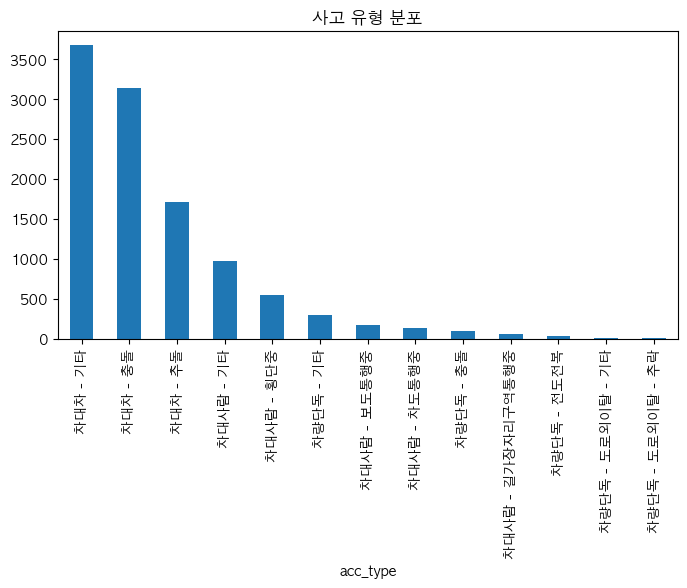

In [15]:
# 사고 유형 분포
import matplotlib.pyplot as plt

accident["acc_type"].value_counts().plot(
    kind="bar",
    figsize=(8,4),
    title="사고 유형 분포"
)

plt.show()

- 차대차 사고가 압도적으로 많음
- 그 다음이 차대사람
-> 도시 교통사고는 기본적으로 차량 간 충돌 중심 구조

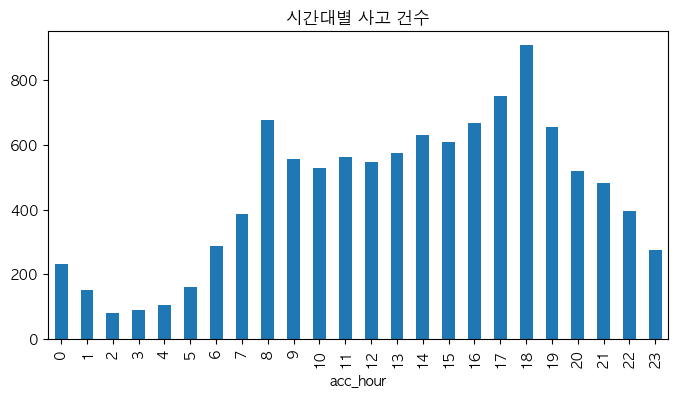

In [16]:
# 시간대별 사고
accident["acc_hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4),
    title="시간대별 사고 건수"
)

plt.show()

In [17]:
def make_time_band(hour):

    if 0 <= hour <= 5:
        return "00-05"
    elif 6 <= hour <= 9:
        return "06-09"
    elif 10 <= hour <= 16:
        return "10-16"
    elif 17 <= hour <= 20:
        return "17-20"
    elif 21 <= hour <= 23:
        return "21-23"
    else:
        return None

accident["time_band"] = accident["acc_hour"].apply(make_time_band)

time_band
00-05     815
06-09    1905
10-16    4116
17-20    2832
21-23    1153
Name: count, dtype: int64


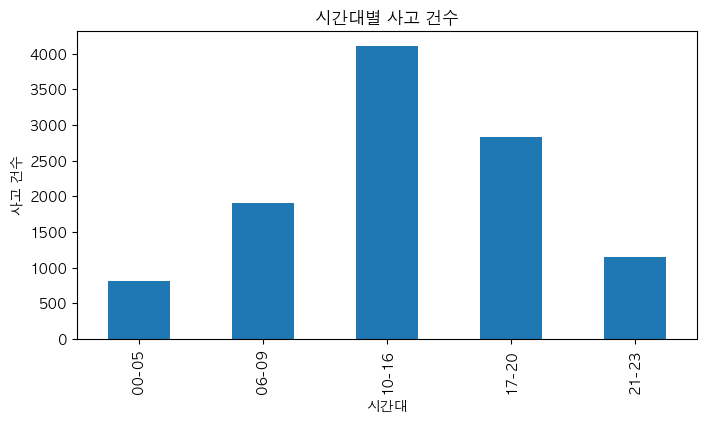

In [18]:
time_band_counts = accident["time_band"].value_counts().sort_index()

print(time_band_counts)

import matplotlib.pyplot as plt

time_band_counts.plot(
    kind="bar",
    figsize=(8,4),
    title="시간대별 사고 건수"
)

plt.xlabel("시간대")
plt.ylabel("사고 건수")
plt.show()

- 사고는 출퇴근 시간보다 생활 활동 시간에 더 많이 발생
- 취약계층의 사고 건수도 확인해봐야할듯

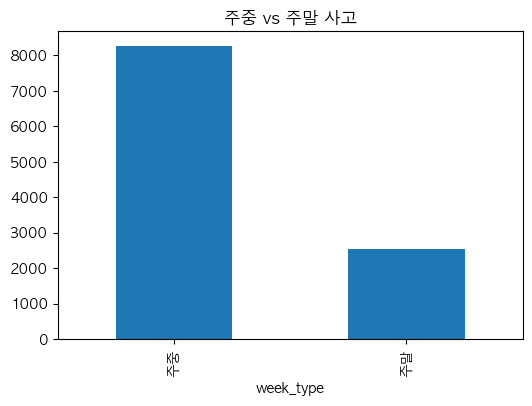

In [19]:
# 주중/주말 사고
accident["week_type"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="주중 vs 주말 사고"
)

plt.show()

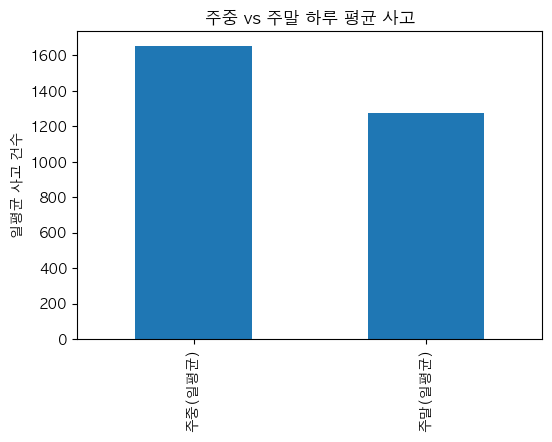

주중(일평균)    1655.0
주말(일평균)    1273.0
dtype: float64


In [20]:
# 주중/주말 - 하루 평균으로 계산
week_counts = accident["week_type"].value_counts()

weekday_avg = week_counts["주중"] / 5
weekend_avg = week_counts["주말"] / 2

week_avg = pd.Series({
    "주중(일평균)": weekday_avg,
    "주말(일평균)": weekend_avg
})

week_avg.plot(
    kind="bar",
    figsize=(6,4),
    title="주중 vs 주말 하루 평균 사고"
)

plt.ylabel("일평균 사고 건수")
plt.show()

print(week_avg)

In [135]:
accident.head()

,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,...,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,geometry,acc_hour,time_band
0,2024,1,주중,19시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,...,이륜,경상,41-50세,0,0,1,0,POINT (967805 1931238),19,17-20
1,2024,1,주중,07시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,...,이륜,부상신고,41-50세,0,0,0,1,POINT (966349 1927868),7,06-09
2,2024,1,주중,10시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,맑음,...,승용,상해없음,51-60세,0,1,0,0,POINT (967987 1934555),10,10-16
3,2024,1,주중,17시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,맑음,...,승용,중상,31-40세,0,1,0,0,POINT (964623 1933493),17,17-20
4,2024,1,주중,23시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,맑음,...,승용,경상,31-40세,0,0,1,0,POINT (964980 1933861),23,21-23


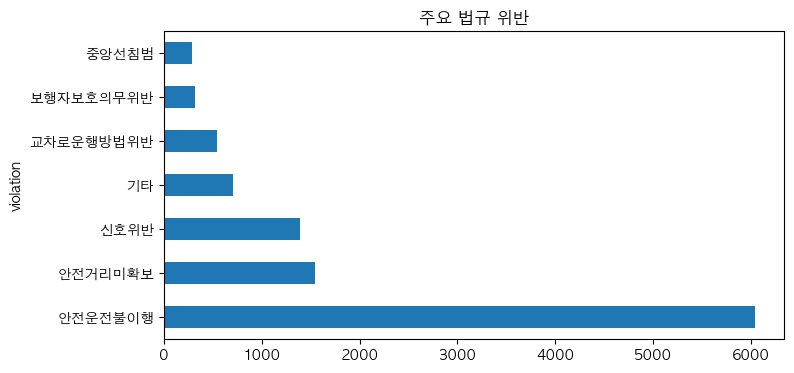

In [21]:
# 법규 위반 유형
accident["violation"].value_counts().head(10).plot(
    kind="barh",
    figsize=(8,4),
    title="주요 법규 위반"
)

plt.show()

- 교통사고의 주요 원인은 안전운전 불이행으로 나타났으며, 이는 단순 운전자 요인뿐 아니라 도로 환경 및 교통 시설 설계와도 밀접한 관련이 있을 가능성을 시사

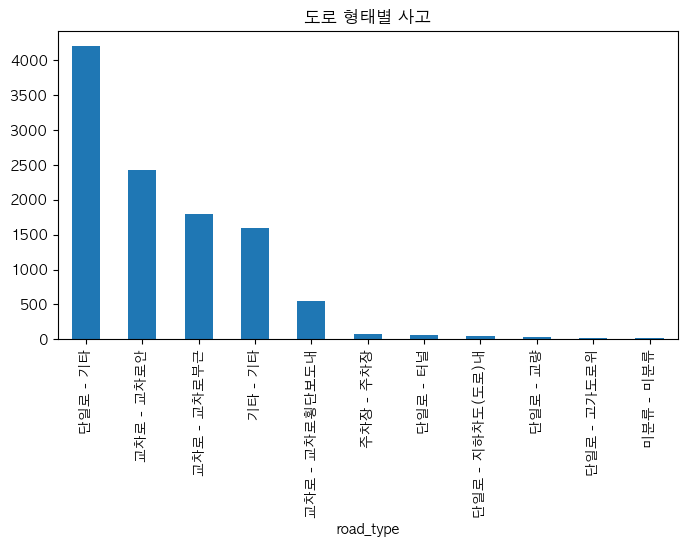

In [22]:
# 도로 형태 
accident["road_type"].value_counts().plot(
    kind="bar",
    figsize=(8,4),
    title="도로 형태별 사고"
)

plt.show()

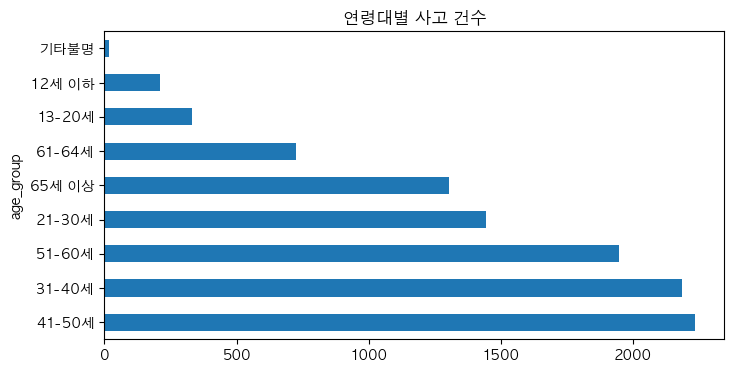

In [23]:
# 연령대 분포
accident.dropna(subset=["age_group"])["age_group"].value_counts().plot(
    kind="barh",
    figsize=(8,4),
    title="연령대별 사고 건수"
)

plt.show()

In [24]:
# 시간대 x 사고유형
pd.crosstab(accident["time_band"], accident["acc_type"])

acc_type,차대사람 - 기타,차대사람 - 길가장자리구역통행중,차대사람 - 보도통행중,차대사람 - 차도통행중,차대사람 - 횡단중,차대차 - 기타,차대차 - 추돌,차대차 - 충돌,차량단독 - 기타,차량단독 - 도로외이탈 - 기타,차량단독 - 도로외이탈 - 추락,차량단독 - 전도전복,차량단독 - 충돌
time_band,,,,,,,,,,,,,
00-05,75,3,7,11,30,256,161,190,40,0,1,12,29
06-09,151,5,17,19,89,635,332,588,43,1,1,3,21
10-16,364,25,72,54,173,1431,630,1225,113,1,1,7,20
17-20,268,18,53,37,171,1000,385,819,62,1,0,3,15
21-23,112,7,17,11,86,356,199,318,33,0,0,2,12


- 낮 시간대 차대사람 사고 비중 높음

In [25]:
# 시간대 x 연령
pd.crosstab(accident["time_band"], accident["age_group"])

age_group,12세 이하,13-20세,21-30세,31-40세,41-50세,51-60세,61-64세,65세 이상,기타불명
time_band,,,,,,,,,
00-05,0,18,118,136,138,151,73,98,1
06-09,19,48,226,362,403,383,118,274,3
10-16,99,106,494,830,853,710,287,590,5
17-20,84,119,409,631,610,468,168,254,8
21-23,10,42,195,227,230,235,78,87,2


- 어린이는 등하교 시간대에 상대적으로 많이 발생하고 노인은 낮 시간대에 많이 발생

## 공간 구조 EDA

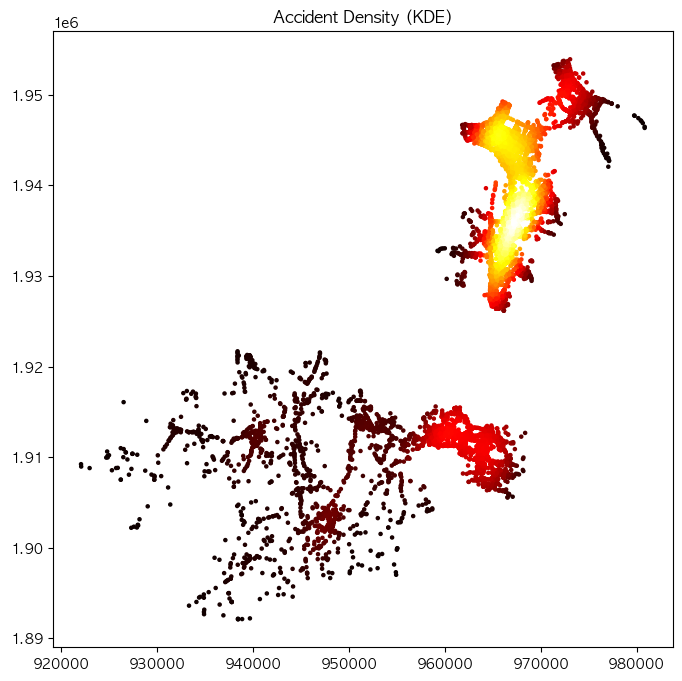

In [26]:
# 사고 KDE
# 사고가 어디에 몰리는지 직관적으로 확인
from scipy.stats import gaussian_kde
import numpy as np

accident = accident.to_crs(epsg=5179)
grid_4 = grid_4.to_crs(epsg=5179)

# 좌표 추출
x = accident.geometry.x
y = accident.geometry.y

xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(
    x,
    y,
    c=z,
    s=5,
    cmap="hot"
)

plt.title("Accident Density (KDE)")
plt.show()

1. 사고는 랜덤이 아니라 군집 형태
- 노란색/흰색 -> 사고 밀도 높음
- 검은 점 -> 사고 드묾

-> 사고가 공간적으로 특정 지역에 집중됨(spatial clustering)
- KDE 분석 결과 교통사고는 공간적으로 균등하게 분포하지 않고 특정 지역에 집중되는 군집 패턴을 보임

2. 사고가 도로 네트워크 따라 발생
- 원형 핫스팟이 아니라 선형 구조를 띔
- 사고가 도로 축 따라 발생
    - 교통량, 도로 구조

3. 지역별 사고 집중 지역 확인
- 도시마다 패턴이 다름 

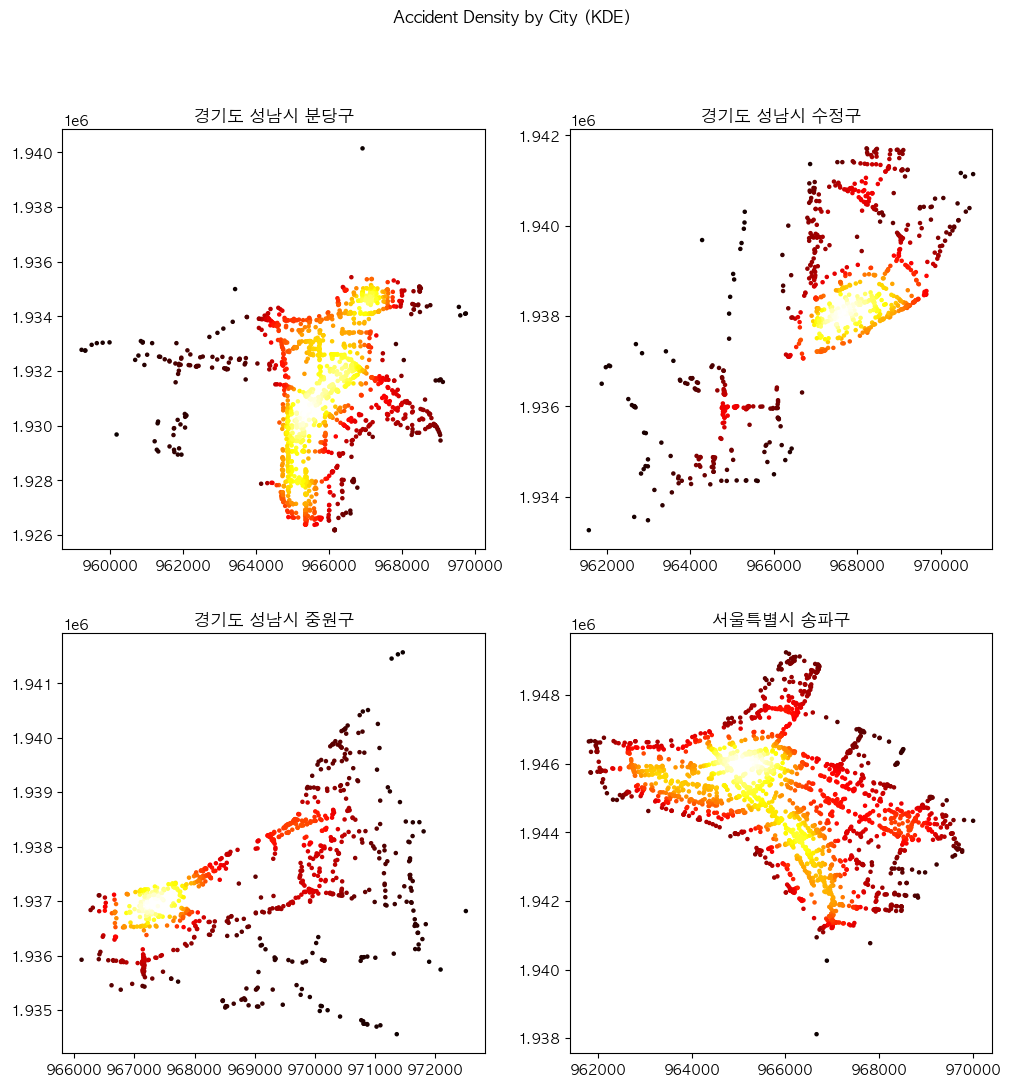

In [27]:
# 도시별로 KDE 분석 
cities = accident["sgg"].unique()

fig, axes = plt.subplots(2,2, figsize=(12,12))

for ax, city in zip(axes.flatten(), cities):

    data = accident[accident["sgg"] == city]

    x = data.geometry.x
    y = data.geometry.y

    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    ax.scatter(
        x,
        y,
        c=z,
        s=5,
        cmap="hot"
    )

    ax.set_title(city)

plt.suptitle("Accident Density by City (KDE)")
plt.show()

1. 공통 패턴: 선형 (linear) 사고 구조
- 사고가 원형이 아니라 도로 축을 따라 길게 분포
-> 사고가 도로 네트워크 중심으로 발생. 이는 교통사고 발생이 도로 네트워크 구조와 밀접하게 연관되어 있음을 시사

2. 중심 생활권 hotspot
- 판교(분당구) -> 중심 상업지/업무지 hotspot
- 위례(송파) -> 중심 생활권 hotspot
- 미사(수정구) -> 중심 상업지 hotspot
- 동찬(중원구) -> 중심 생활권 hotspot

3. 교통축 hotspot
- 위례, 판교에서 방사형 교통축이 나타남. 이건 보통 간선도로, 교차로 밀집지역
    - 확인해보장~

4. 도시별 차이
- 도시마다 사고 패턴이 다름 
    - 판교: 중심 집중형
    - 동탄: 선형 교통축형

- KDE로 핫스팟 위치 확인햇고 Moran's I랑 Getis-Ord Gi*로 핫스팟 위치 검정 ㄱ

In [28]:
accident_grid = gpd.sjoin(
    accident,
    grid_4[["gid", "geometry"]],
    how="left",
    predicate="within"
)

grid_acc = accident_grid.groupby("gid").size().reset_index(name="acc_count")

grid_4 = grid_4.drop(columns=["acc_count"], errors="ignore")

grid_4 = grid_4.merge(grid_acc, on="gid", how="left")

grid_4["acc_count"] = grid_4["acc_count"].fillna(0)

In [29]:
grid_4.columns

Index(['std_yr', 'gbn', 'gid', 'geometry', 'acc_count'], dtype='object')

In [30]:
print("원본 사고 건수:", len(accident))
print("격자 집계 합:", grid_4["acc_count"].sum())
print("매핑 안 된 사고 수:", accident_grid["gid"].isna().sum())

원본 사고 건수: 10821
격자 집계 합: 11155.0
매핑 안 된 사고 수: 17


In [31]:
print("grid 개수:", len(grid_4))
print("gid 고유 개수:", grid_4["gid"].nunique())

dup_gid = grid_4[grid_4["gid"].duplicated(keep=False)].sort_values("gid")
print("중복 gid 행 수:", len(dup_gid))
display(dup_gid.head(20))

grid 개수: 99323
gid 고유 개수: 99146
중복 gid 행 수: 353


,std_yr,gbn,gid,geometry,acc_count
8165,2024,경기도 성남시,다사667408,"POLYGON ((966700 1940800, 966700 1940900, 9668...",0.0
97967,2024,서울특별시 송파구,다사667408,"POLYGON ((966700 1940800, 966700 1940900, 9668...",0.0
97968,2024,서울특별시 송파구,다사667409,"POLYGON ((966700 1940900, 966700 1941000, 9668...",0.0
8166,2024,경기도 성남시,다사667409,"POLYGON ((966700 1940900, 966700 1941000, 9668...",0.0
8311,2024,경기도 성남시,다사668409,"POLYGON ((966800 1940900, 966800 1941000, 9669...",2.0
98036,2024,서울특별시 송파구,다사668409,"POLYGON ((966800 1940900, 966800 1941000, 9669...",2.0
98037,2024,서울특별시 송파구,다사668410,"POLYGON ((966800 1941000, 966800 1941100, 9669...",2.0
8312,2024,경기도 성남시,다사668410,"POLYGON ((966800 1941000, 966800 1941100, 9669...",2.0
8313,2024,경기도 성남시,다사668411,"POLYGON ((966800 1941100, 966800 1941200, 9669...",0.0
98038,2024,서울특별시 송파구,다사668411,"POLYGON ((966800 1941100, 966800 1941200, 9669...",0.0


In [ ]:
import folium
import branca.colormap as cm

# 1️⃣ 좌표계 변환
grid_4 = grid_4.to_crs(epsg=4326)

# 2️⃣ 중심 좌표
center = [
    grid_4.geometry.centroid.y.mean(),
    grid_4.geometry.centroid.x.mean()
]

# 3️⃣ 지도 생성
m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

# 4️⃣ 컬러맵
colormap = cm.linear.YlOrRd_09.scale(
    grid_4["acc_count"].min(),
    grid_4["acc_count"].max()
)

# 5️⃣ 시각화
folium.GeoJson(
    grid_4,
    style_function=lambda feature: {
        'fillColor': colormap(feature['properties']['acc_count']),
        'color': 'black',
        'weight': 0.2,
        'fillOpacity': 0.7
    }
).add_to(m)

colormap.add_to(m)

m

/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/2933716821.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_4.geometry.centroid.y.mean(),
/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/2933716821.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_4.geometry.centroid.x.mean()


In [173]:
m.save("accident_grid_map.html")

In [32]:
grid_4_clean = grid_4.drop_duplicates(subset="gid").copy()

In [33]:
import numpy as np

## Queen 인접행렬 만들기
# 분석용 데이터
gdf = grid_4_clean.reset_index(drop=True).copy()

# 공간 인덱스
sindex = gdf.sindex

# Queen contiguity 이웃 리스트 만들기
neighbors = {}

for i, geom in enumerate(gdf.geometry):
    candidate_idx = list(sindex.intersection(geom.bounds))
    candidate_idx = [j for j in candidate_idx if j != i]
    
    neigh = []
    for j in candidate_idx:
        if geom.touches(gdf.geometry.iloc[j]):
            neigh.append(j)
    neighbors[i] = neigh

# 확인
print("평균 이웃 수:", np.mean([len(v) for v in neighbors.values()]))

평균 이웃 수: 7.861799770036108


In [34]:
# Moran's I 계산

x = gdf["acc_count"].values.astype(float)
x_bar = x.mean()
z = x - x_bar
n = len(x)

# S0 = 모든 가중치 합
S0 = sum(len(v) for v in neighbors.values())

# 분자
num = 0.0
for i, neighs in neighbors.items():
    for j in neighs:
        num += z[i] * z[j]

# 분모
den = np.sum(z**2)

moran_I = (n / S0) * (num / den)
print("Moran's I:", moran_I)

Moran's I: 0.2836332216178067


In [35]:
# 유의성 검정까지 하려면 permutation

import random

def moran_stat(values, neighbors):
    values = np.asarray(values, dtype=float)
    z = values - values.mean()
    n = len(values)
    S0 = sum(len(v) for v in neighbors.values())
    num = 0.0
    for i, neighs in neighbors.items():
        for j in neighs:
            num += z[i] * z[j]
    den = np.sum(z**2)
    return (n / S0) * (num / den)

observed_I = moran_stat(gdf["acc_count"].values, neighbors)

# permutation test
n_perm = 999
perm_I = []

vals = gdf["acc_count"].values.copy()
for _ in range(n_perm):
    shuffled = np.random.permutation(vals)
    perm_I.append(moran_stat(shuffled, neighbors))

perm_I = np.array(perm_I)

# 양측 p-value
p_value = (np.sum(np.abs(perm_I) >= np.abs(observed_I)) + 1) / (n_perm + 1)

print("Observed Moran's I:", observed_I)
print("Permutation p-value:", p_value)

Observed Moran's I: 0.2836332216178067
Permutation p-value: 0.001


**Moran's I 해석**
- Moran's I = 0.2836
- p-value = 0.001

- 사고가 랜덤하게 퍼져 있지 않음
- 사고가 많은 격자 주변에 사고가 많은 격자가 모이는 경향 존재

-> 격자별 교통사고는 공간적으로 유의한 양의 자기상관을 보이며, 특정 지역에 군집되는 특성이 확인됨

In [36]:
(gdf["acc_count"] == 0).mean()

np.float64(0.942216529159018)

- 보통 교통 데이터는 0.8~0.95정도 나옴

In [37]:
# Getis-Ord Gi* 계산


# 분석용 데이터
gdf = grid_4_clean.reset_index(drop=True).copy()

# 사고 건수
x = gdf["acc_count"].values.astype(float)

# 전체 평균 / 표준편차
n = len(x)
x_bar = x.mean()
S = x.std(ddof=1)

# Gi* 저장
gi_star = np.zeros(n)

for i in range(n):
    # self 포함 이웃
    neighs = neighbors[i] + [i]
    
    # 가중치: 이웃이면 1, 아니면 0
    w_i = np.zeros(n)
    w_i[neighs] = 1
    
    sum_wx = np.sum(w_i * x)
    sum_w = np.sum(w_i)
    sum_w2 = np.sum(w_i ** 2)
    
    numerator = sum_wx - x_bar * sum_w
    denominator = S * np.sqrt((n * sum_w2 - sum_w**2) / (n - 1))
    
    if denominator != 0:
        gi_star[i] = numerator / denominator
    else:
        gi_star[i] = np.nan

# 결과 붙이기
gdf["Gi_star_z"] = gi_star

In [38]:
def classify_gi(z):
    if pd.isna(z):
        return "NA"
    elif z > 2.58:
        return "Hotspot 99%"
    elif z > 1.96:
        return "Hotspot 95%"
    elif z < -2.58:
        return "Coldspot 99%"
    elif z < -1.96:
        return "Coldspot 95%"
    else:
        return "Not Significant"

gdf["Gi_class"] = gdf["Gi_star_z"].apply(classify_gi)

In [39]:
print(gdf["Gi_class"].value_counts(dropna=False))
print(gdf["Gi_star_z"].describe())

Gi_class
Not Significant    92796
Hotspot 99%         5229
Hotspot 95%         1121
Name: count, dtype: int64
count    99146.000000
mean         0.003461
std          1.709905
min         -0.526639
25%         -0.526639
50%         -0.526639
75%         -0.429993
max         46.230266
Name: Gi_star_z, dtype: float64


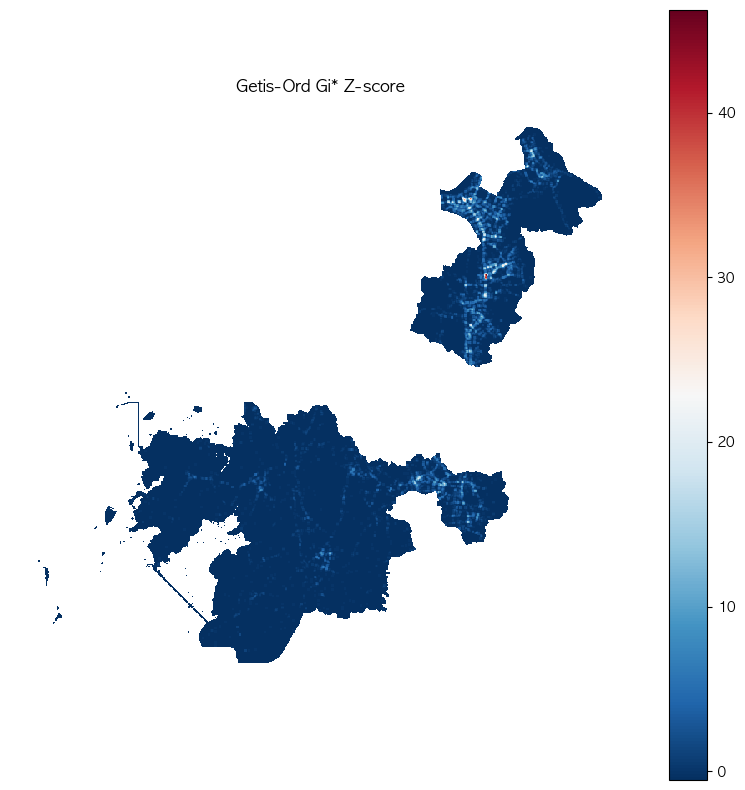

In [40]:
# z-score 연속값 지도
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Gi_star_z",
    cmap="RdBu_r",   # hotspot 빨강, coldspot 파랑 느낌
    legend=True,
    ax=ax,
    linewidth=0
)

plt.title("Getis-Ord Gi* Z-score")
plt.axis("off")
plt.show()

/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/149877471.py:14: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf["Gi_class"] == cls].plot(
/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/149877471.py:14: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf["Gi_class"] == cls].plot(
/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/149877471.py:14: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf["Gi_class"] == cls].plot(
/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/149877471.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/149877471.

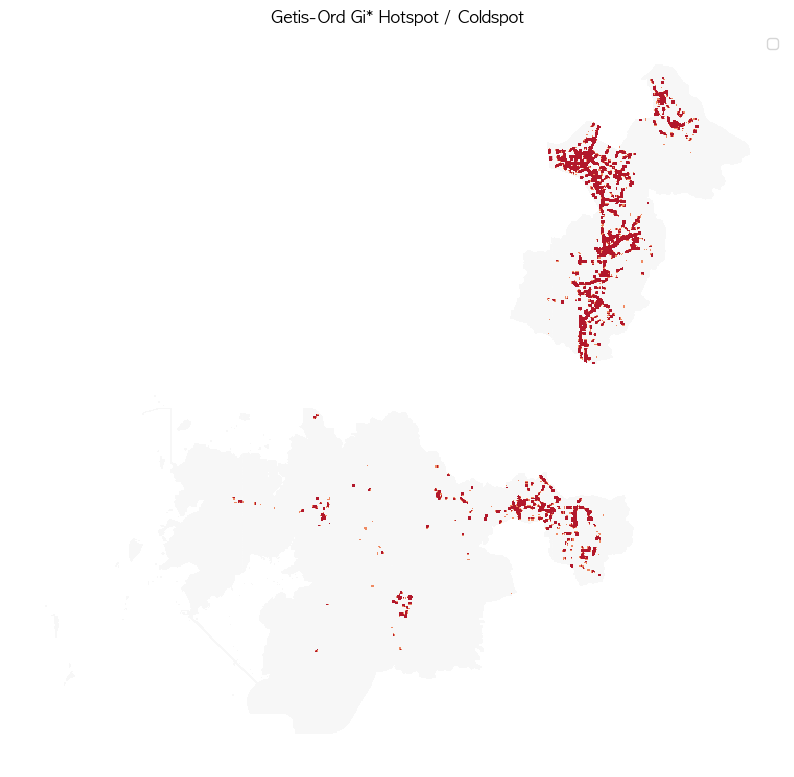

In [41]:
# class 기반 지도
color_map = {
    "Hotspot 99%": "#b2182b",
    "Hotspot 95%": "#ef8a62",
    "Not Significant": "#f7f7f7",
    "Coldspot 95%": "#67a9cf",
    "Coldspot 99%": "#2166ac",
    "NA": "#cccccc"
}

fig, ax = plt.subplots(figsize=(10, 10))

for cls, color in color_map.items():
    gdf[gdf["Gi_class"] == cls].plot(
        ax=ax,
        color=color,
        linewidth=0,
        label=cls
    )

plt.title("Getis-Ord Gi* Hotspot / Coldspot")
plt.legend()
plt.axis("off")
plt.show()

### 도시별로 Morans'I & Getis-Ord GI*

In [42]:
# 도시별 Moran's I 계산

import geopandas as gpd

# -----------------------------
# Queen 이웃 리스트 만드는 함수
# -----------------------------
def make_queen_neighbors(gdf):
    gdf = gdf.reset_index(drop=True).copy()
    sindex = gdf.sindex
    neighbors = {}

    for i, geom in enumerate(gdf.geometry):
        candidate_idx = list(sindex.intersection(geom.bounds))
        candidate_idx = [j for j in candidate_idx if j != i]

        neigh = []
        for j in candidate_idx:
            if geom.touches(gdf.geometry.iloc[j]):
                neigh.append(j)
        neighbors[i] = neigh

    return neighbors

# -----------------------------
# Moran's I 계산 함수
# -----------------------------
def moran_stat(values, neighbors):
    values = np.asarray(values, dtype=float)
    z = values - values.mean()
    n = len(values)
    S0 = sum(len(v) for v in neighbors.values())

    num = 0.0
    for i, neighs in neighbors.items():
        for j in neighs:
            num += z[i] * z[j]

    den = np.sum(z**2)

    if S0 == 0 or den == 0:
        return np.nan

    return (n / S0) * (num / den)

# -----------------------------
# permutation p-value 함수
# -----------------------------
def moran_permutation_test(values, neighbors, n_perm=999, seed=42):
    np.random.seed(seed)

    observed_I = moran_stat(values, neighbors)

    perm_I = []
    vals = np.asarray(values).copy()

    for _ in range(n_perm):
        shuffled = np.random.permutation(vals)
        perm_I.append(moran_stat(shuffled, neighbors))

    perm_I = np.array(perm_I)

    p_value = (np.sum(np.abs(perm_I) >= np.abs(observed_I)) + 1) / (n_perm + 1)

    return observed_I, p_value, perm_I

# -----------------------------
# 도시별 Moran's I
# -----------------------------
moran_results = []

for city in sorted(grid_4_clean["gbn"].dropna().unique()):
    city_gdf = grid_4_clean[grid_4_clean["gbn"] == city].copy().reset_index(drop=True)

    # 사고 건수가 전부 0이면 skip
    if city_gdf["acc_count"].sum() == 0:
        continue

    neighbors = make_queen_neighbors(city_gdf)
    observed_I, p_value, perm_I = moran_permutation_test(
        city_gdf["acc_count"].values,
        neighbors,
        n_perm=999,
        seed=42
    )

    moran_results.append({
        "city": city,
        "n_grid": len(city_gdf),
        "mean_neighbors": np.mean([len(v) for v in neighbors.values()]),
        "moran_I": observed_I,
        "p_value": p_value
    })

moran_results_df = pd.DataFrame(moran_results).sort_values("moran_I", ascending=False)
display(moran_results_df)

,city,n_grid,mean_neighbors,moran_I,p_value
0,경기도 성남시,14513,7.879143,0.296533,0.001
1,경기도 하남시,9589,7.832516,0.237827,0.001
3,서울특별시 송파구,3445,7.742816,0.230320,0.001
2,경기도 화성시,71599,7.856227,0.195339,0.001


- 모든 도시에서 교통사고는 공간적으로 랜덤이 아니라 군집함
- 도시별 clustering 강도 차이 존재

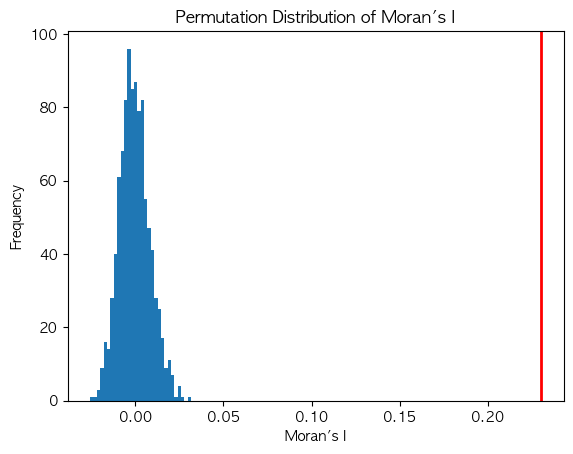

In [136]:
import matplotlib.pyplot as plt

plt.hist(perm_I, bins=30)
plt.axvline(observed_I, color='red', linewidth=2)
plt.title("Permutation Distribution of Moran's I")
plt.xlabel("Moran's I")
plt.ylabel("Frequency")
plt.show()

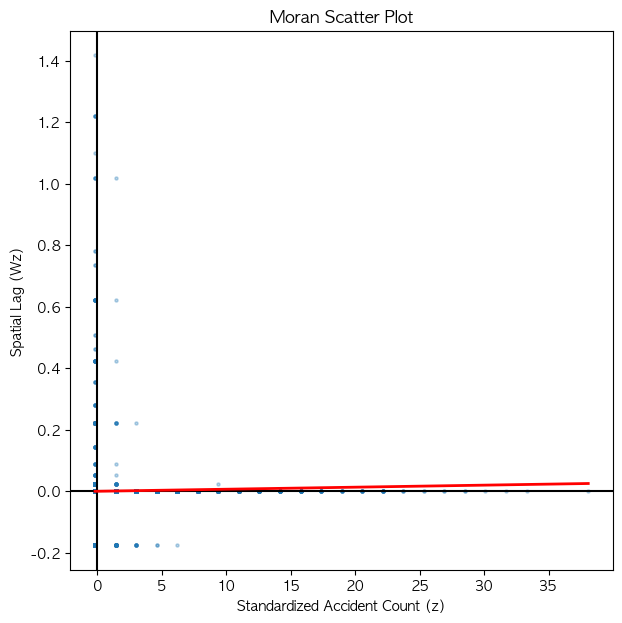

In [139]:
import numpy as np
import matplotlib.pyplot as plt

x = gdf["acc_count"].astype(float).values

# 표준화 (중요)
z = (x - x.mean()) / x.std()

lag_z = np.zeros(len(gdf))

for i in range(len(gdf)):
    neighs = neighbors.get(i, [])
    if len(neighs) > 0:
        lag_z[i] = z[neighs].mean()

# 회귀선
slope = np.polyfit(z, lag_z, 1)[0]

plt.figure(figsize=(7,7))
plt.scatter(z, lag_z, alpha=0.3, s=5)

plt.axhline(0, color='black')
plt.axvline(0, color='black')

x_line = np.linspace(z.min(), z.max(), 100)
plt.plot(x_line, slope * x_line, color='red', linewidth=2)

plt.xlabel("Standardized Accident Count (z)")
plt.ylabel("Spatial Lag (Wz)")
plt.title("Moran Scatter Plot")

plt.show()

In [43]:
# 도시별 Getis-Ord Gi* 계산

# -----------------------------
# Getis-Ord Gi* 계산 함수
# self 포함형
# -----------------------------
def compute_gi_star(gdf, neighbors, value_col="acc_count"):
    x = gdf[value_col].values.astype(float)
    n = len(x)
    x_bar = x.mean()
    S = x.std(ddof=1)

    gi_star = np.zeros(n)

    for i in range(n):
        # self 포함
        neighs = neighbors[i] + [i]

        w_i = np.zeros(n)
        w_i[neighs] = 1

        sum_wx = np.sum(w_i * x)
        sum_w = np.sum(w_i)
        sum_w2 = np.sum(w_i ** 2)

        numerator = sum_wx - x_bar * sum_w
        denominator = S * np.sqrt((n * sum_w2 - sum_w**2) / (n - 1))

        if denominator != 0:
            gi_star[i] = numerator / denominator
        else:
            gi_star[i] = np.nan

    return gi_star

# -----------------------------
# Gi* 등급 분류
# -----------------------------
def classify_gi(z):
    if pd.isna(z):
        return "NA"
    elif z > 2.58:
        return "Hotspot 99%"
    elif z > 1.96:
        return "Hotspot 95%"
    elif z < -2.58:
        return "Coldspot 99%"
    elif z < -1.96:
        return "Coldspot 95%"
    else:
        return "Not Significant"

# -----------------------------
# 도시별 Gi* 계산
# -----------------------------
gi_city_list = []

for city in sorted(grid_4_clean["gbn"].dropna().unique()):
    city_gdf = grid_4_clean[grid_4_clean["gbn"] == city].copy().reset_index(drop=True)

    if city_gdf["acc_count"].sum() == 0:
        continue

    neighbors = make_queen_neighbors(city_gdf)
    city_gdf["Gi_star_z"] = compute_gi_star(city_gdf, neighbors, value_col="acc_count")
    city_gdf["Gi_class"] = city_gdf["Gi_star_z"].apply(classify_gi)

    gi_city_list.append(city_gdf)

gi_result = pd.concat(gi_city_list, ignore_index=True)

display(gi_result[["gbn", "gid", "acc_count", "Gi_star_z", "Gi_class"]].head())

,gbn,gid,acc_count,Gi_star_z,Gi_class
0,경기도 성남시,다사581304,0.0,-0.499977,Not Significant
1,경기도 성남시,다사581305,0.0,-0.612386,Not Significant
2,경기도 성남시,다사581306,0.0,-0.559010,Not Significant
3,경기도 성남시,다사582304,0.0,-0.612386,Not Significant
4,경기도 성남시,다사582305,0.0,-0.750095,Not Significant


In [44]:
# 도시별 Gi_class 요약
gi_summary = (
    gi_result.groupby(["gbn", "Gi_class"])
    .size()
    .unstack(fill_value=0)
)

display(gi_summary)

Gi_class,Hotspot 95%,Hotspot 99%,Not Significant
gbn,,,
경기도 성남시,341,917,13255
경기도 하남시,115,470,9004
경기도 화성시,1142,2581,67876
서울특별시 송파구,109,219,3117


In [45]:
# 도시별 핫스팟 개수
gi_hotspot_summary = gi_result.groupby("gbn").apply(
    lambda x: pd.Series({
        "Hotspot 99%": (x["Gi_class"] == "Hotspot 99%").sum(),
        "Hotspot 95%": (x["Gi_class"] == "Hotspot 95%").sum(),
        "Coldspot 99%": (x["Gi_class"] == "Coldspot 99%").sum(),
        "Coldspot 95%": (x["Gi_class"] == "Coldspot 95%").sum(),
        "Not Significant": (x["Gi_class"] == "Not Significant").sum()
    })
).reset_index()

display(gi_hotspot_summary)

/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/2893962969.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gi_hotspot_summary = gi_result.groupby("gbn").apply(


,gbn,Hotspot 99%,Hotspot 95%,Coldspot 99%,Coldspot 95%,Not Significant
0,경기도 성남시,917,341,0,0,13255
1,경기도 하남시,470,115,0,0,9004
2,경기도 화성시,2581,1142,0,0,67876
3,서울특별시 송파구,219,109,0,0,3117


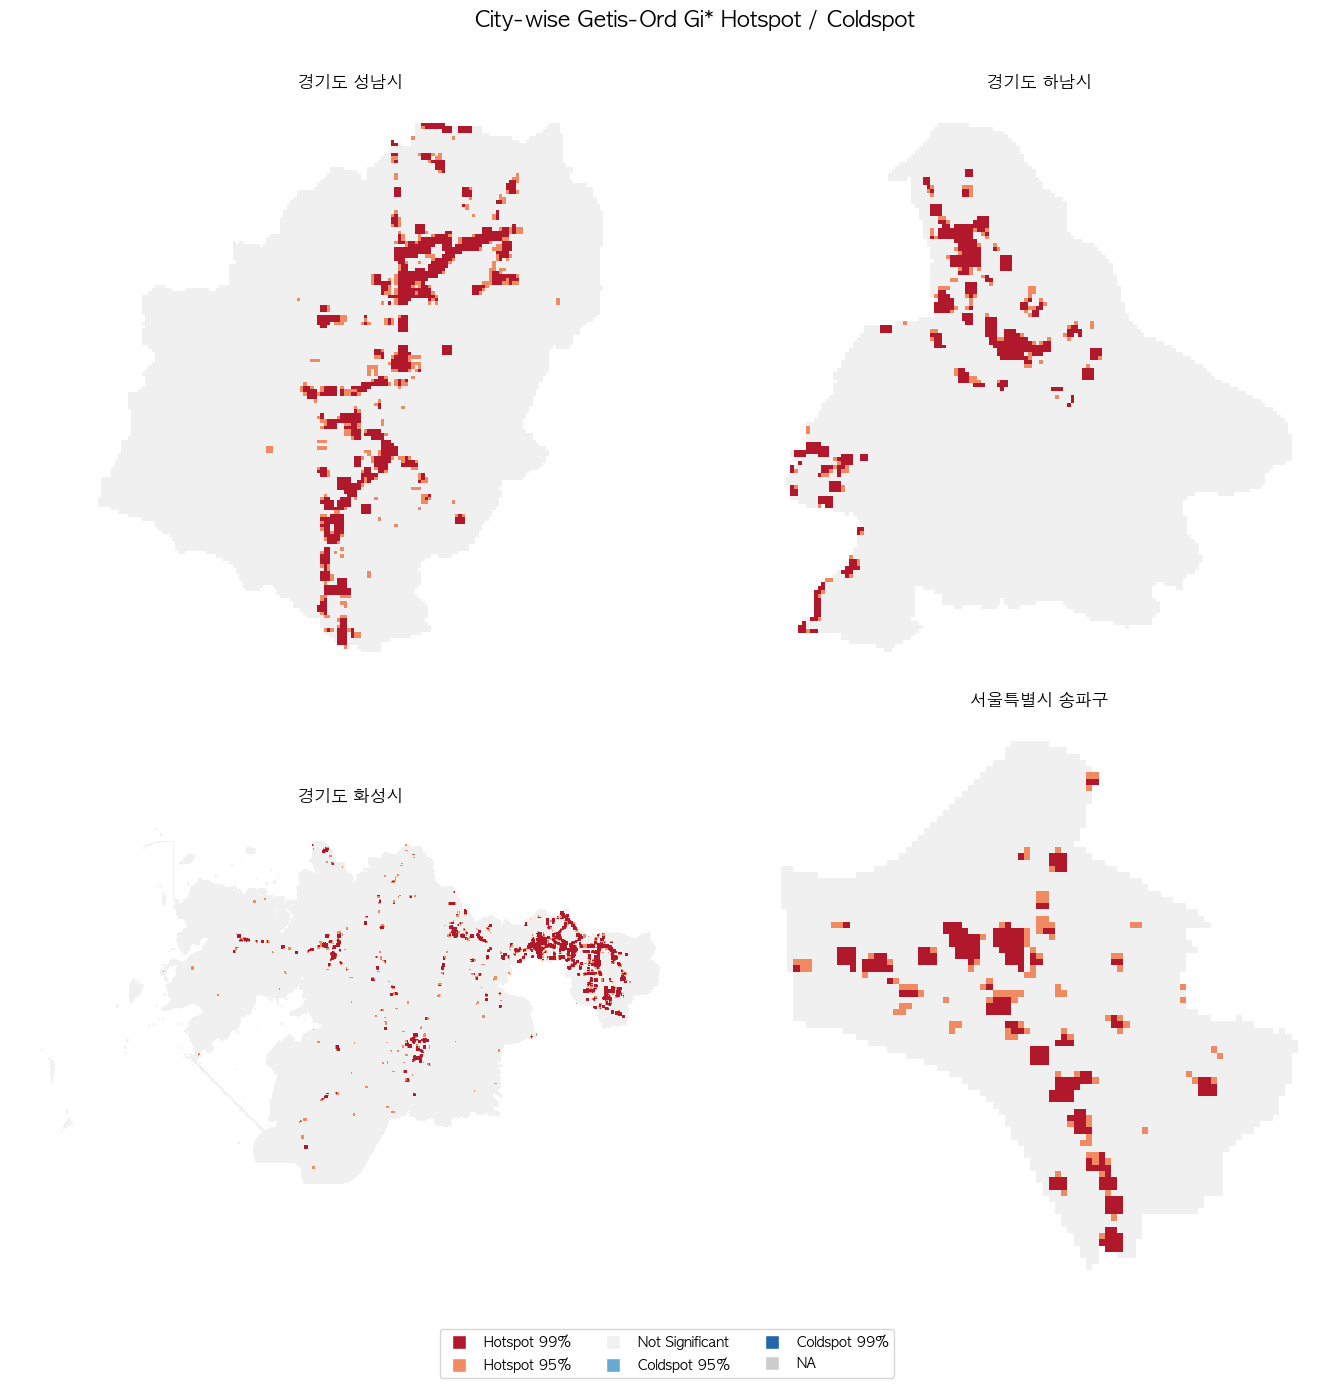

In [46]:
# 도시별 Getis-Ord Gi* 지도

# 도시별  패널 지도
import matplotlib.pyplot as plt

color_map = {
    "Hotspot 99%": "#b2182b",
    "Hotspot 95%": "#ef8a62",
    "Not Significant": "#f0f0f0",
    "Coldspot 95%": "#67a9cf",
    "Coldspot 99%": "#2166ac",
    "NA": "#cccccc"
}

cities = sorted(gi_result["gbn"].dropna().unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, city in zip(axes, cities):
    city_gdf = gi_result[gi_result["gbn"] == city].copy()

    for cls, color in color_map.items():
        subset = city_gdf[city_gdf["Gi_class"] == cls]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, linewidth=0)

    ax.set_title(city, fontsize=12)
    ax.axis("off")

# 범례는 마지막에 수동 생성
handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10, label=cls)
    for cls, color in color_map.items()
]
fig.legend(handles=handles, loc="lower center", ncol=3)

plt.suptitle("City-wise Getis-Ord Gi* Hotspot / Coldspot", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

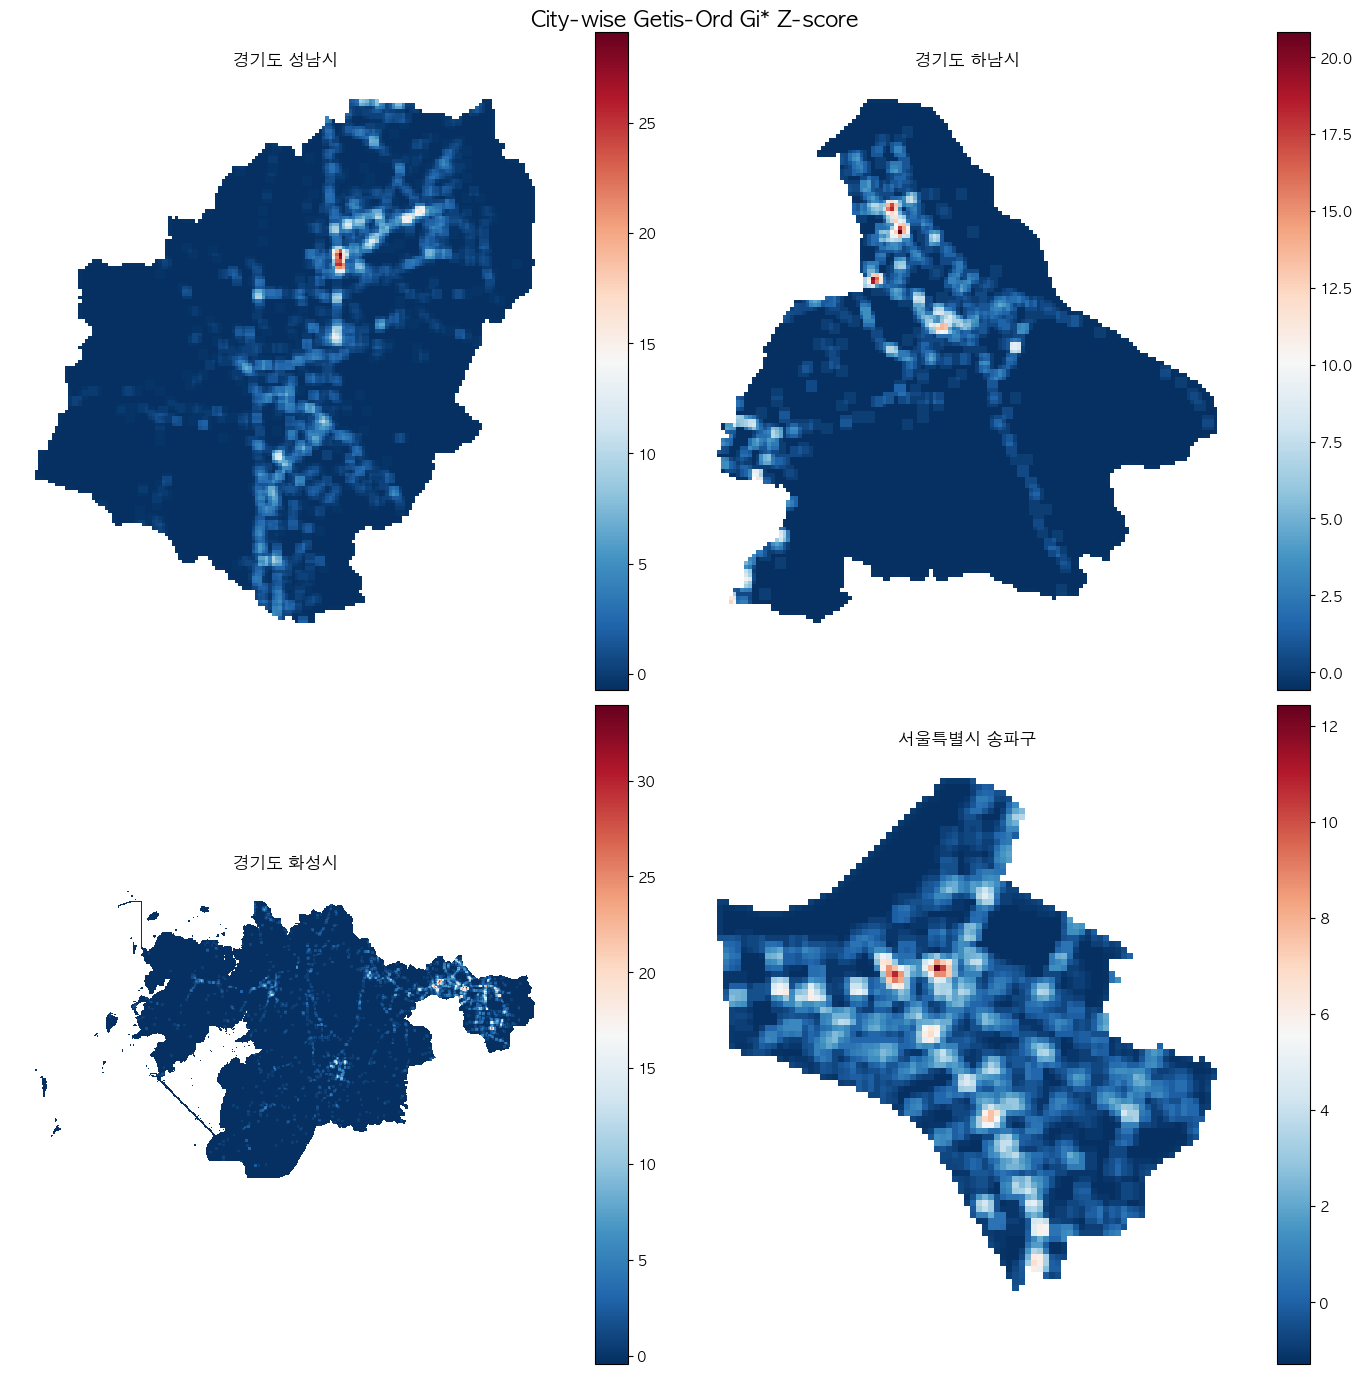

In [47]:
# 도시별 z-score 연속값 지도
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, city in zip(axes, cities):
    city_gdf = gi_result[gi_result["gbn"] == city].copy()

    city_gdf.plot(
        column="Gi_star_z",
        cmap="RdBu_r",
        legend=True,
        ax=ax,
        linewidth=0
    )

    ax.set_title(city, fontsize=12)
    ax.axis("off")

plt.suptitle("City-wise Getis-Ord Gi* Z-score", fontsize=16)
plt.tight_layout()
plt.show()

In [48]:
# hotspot만 따로 뽑기
hotspot_95 = gi_result[gi_result["Gi_star_z"] > 1.96].copy()
coldspot_95 = gi_result[gi_result["Gi_star_z"] < -1.96].copy()

print("전체 95% hotspot 격자 수:", len(hotspot_95))
print("전체 95% coldspot 격자 수:", len(coldspot_95))

전체 95% hotspot 격자 수: 5894
전체 95% coldspot 격자 수: 0


In [49]:
# hotspot 비율 계산
gi_ratio = gi_hotspot_summary.copy()

gi_ratio["total"] = (
    gi_ratio["Hotspot 99%"]
    + gi_ratio["Hotspot 95%"]
    + gi_ratio["Not Significant"]
)

gi_ratio["hotspot_ratio"] = (
    gi_ratio["Hotspot 99%"] + gi_ratio["Hotspot 95%"]
) / gi_ratio["total"]

display(gi_ratio[["gbn","hotspot_ratio"]])

,gbn,hotspot_ratio
0,경기도 성남시,0.086681
1,경기도 하남시,0.061007
2,경기도 화성시,0.051998
3,서울특별시 송파구,0.095210


- 사고 hotspot은 도로 축을 따라 선형적으로 분포하는 경향을 보임 

In [50]:
# 핫스팟에 사고가 얼마나 있는지 

hotspot_acc = (
    gi_result.assign(
        is_hotspot = gi_result["Gi_star_z"] > 1.96
    )
    .groupby("gbn")
    .apply(lambda x: pd.Series({
        "total_acc": x["acc_count"].sum(),
        "hotspot_acc": x.loc[x["is_hotspot"], "acc_count"].sum()
    }))
    .reset_index()
)

hotspot_acc["hotspot_acc_ratio"] = (
    hotspot_acc["hotspot_acc"] /
    hotspot_acc["total_acc"]
)

display(hotspot_acc)

/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/1268579459.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gi_result.assign(


,gbn,total_acc,hotspot_acc,hotspot_acc_ratio
0,경기도 성남시,3564.0,2238.0,0.627946
1,경기도 하남시,1237.0,805.0,0.650768
2,경기도 화성시,3688.0,2629.0,0.712852
3,서울특별시 송파구,2430.0,1040.0,0.427984


1. 화성
- 사고의 71%가 특정 구간에 집중됨
- 사고가 특정 도로 축에 강하게 몰림

2. 하남 미사
- 사고의 65%가 hotspot에서 발생
- 상업지 + 교차로 중심 사고 

3. 판교
- 출퇴근 교통 축 중심 사고

4. 위례
- 약 43%로 사고가 상대적으로 분산 
- 여러 생활권에서 사고 발생

### non-hotspot vs hotspot 비교

In [ ]:
# hotspot vs non-hotspot 사고 비교
gi_result["is_hotspot"] = gi_result["Gi_star_z"] > 1.96

gi_result.groupby("is_hotspot")["acc_count"].agg([
    "mean","sum","count"
])

,mean,sum,count
is_hotspot,,,
False,0.045114,4207.0,93252
True,1.138785,6712.0,5894


In [52]:
# hotspot 도시별 비교

gi_result.groupby(["gbn","is_hotspot"]).size().unstack()

is_hotspot,False,True
gbn,,
경기도 성남시,13255,1258
경기도 하남시,9004,585
경기도 화성시,67876,3723
서울특별시 송파구,3117,328


In [58]:
model_df = pd.read_csv("train_base.csv")
model_df.shape
model_df.head()

,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,POLYGON ((127.02677465735422 37.37172194466841...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,POLYGON ((127.02676899519032 37.37262330005522...,0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
2,다사581306,경기도 성남시,POLYGON ((127.02676333277432 37.37352465530359...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
3,다사582304,경기도 성남시,POLYGON ((127.02790403835982 37.37172645813172...,0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
4,다사582305,경기도 성남시,POLYGON ((127.02789838970781 37.37262781366482...,0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


In [59]:
model_df.isna().sum()

gid                0
city               0
geometry           0
acc_cnt            0
acc_binary         0
resident_pop       0
flow_pop           0
working_pop        0
visit_pop          0
service_pop        0
mean_speed         0
traffic_volume     0
congestion_freq    0
congestion_time    0
crosswalk_count    0
bus_stop_count     0
school_count       0
kinder_count       0
daycare_count      0
cctv_count         0
speedbump_count    0
blockType_main     0
landuse_group      0
is_residential     0
is_commercial      0
is_green           0
is_road            0
is_public          0
dtype: int64

In [62]:
print(model_df.columns.tolist())
print(gi_result.columns.tolist())

['gid', 'city', 'geometry', 'acc_cnt', 'acc_binary', 'resident_pop', 'flow_pop', 'working_pop', 'visit_pop', 'service_pop', 'mean_speed', 'traffic_volume', 'congestion_freq', 'congestion_time', 'crosswalk_count', 'bus_stop_count', 'school_count', 'kinder_count', 'daycare_count', 'cctv_count', 'speedbump_count', 'blockType_main', 'landuse_group', 'is_residential', 'is_commercial', 'is_green', 'is_road', 'is_public', 'cluster']
['std_yr', 'gbn', 'gid', 'geometry', 'acc_count', 'Gi_star_z', 'Gi_class', 'is_hotspot']


In [63]:
print(len(model_df))
print(model_df["gid"].nunique())

print(len(gi_result))
print(gi_result["gid"].nunique())

105032
99146
99146
99146


In [64]:
dup_gid = model_df[model_df["gid"].duplicated(keep=False)]

print(len(dup_gid))
dup_gid.head(20)

8155


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public,cluster
1524,다사611327,경기도 성남시,"POLYGON ((127.060535228784 37.392583893904686,...",0,0,51.750958,2.249058,0.210026,2.039032,0.187419,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1525,다사611327,경기도 성남시,"POLYGON ((127.060535228784 37.392583893904686,...",0,0,48.857791,2.249058,0.210026,2.039032,0.187419,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1526,다사611327,경기도 성남시,"POLYGON ((127.060535228784 37.392583893904686,...",0,0,52.259697,2.249058,0.210026,2.039032,0.187419,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1527,다사611328,경기도 성남시,POLYGON ((127.06052996659488 37.39348525034560...,0,0,2.399051,0.903488,0.085151,0.818337,0.075101,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1528,다사611328,경기도 성남시,POLYGON ((127.06052996659488 37.39348525034560...,0,0,2.422635,0.903488,0.085151,0.818337,0.075101,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1605,다사612327,경기도 성남시,POLYGON ((127.06166492800632 37.39258808697424...,0,0,6.071098,1.077839,0.148346,0.929493,0.089825,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1606,다사612327,경기도 성남시,POLYGON ((127.06166492800632 37.39258808697424...,0,0,16.858360,1.077839,0.148346,0.929493,0.089825,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1607,다사612327,경기도 성남시,POLYGON ((127.06166492800632 37.39258808697424...,0,0,5.025924,1.077839,0.148346,0.929493,0.089825,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1608,다사612327,경기도 성남시,POLYGON ((127.06166492800632 37.39258808697424...,0,0,4.112659,1.077839,0.148346,0.929493,0.089825,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral
1609,다사612327,경기도 성남시,POLYGON ((127.06166492800632 37.39258808697424...,0,0,3.882738,1.077839,0.148346,0.929493,0.089825,...,0.0,0.0,연립,residential,1,0,0,0,0,neutral


In [68]:
model_df = model_df.drop_duplicates()

In [70]:
model_df_clean = (
    model_df
    .groupby("gid", as_index=False)
    .agg({
        "city": "first",
        "geometry": "first",

        "acc_cnt": "first",
        "acc_binary": "first",

        "resident_pop": "mean",

        "flow_pop": "first",
        "working_pop": "first",
        "visit_pop": "first",
        "service_pop": "first",

        "mean_speed": "first",
        "traffic_volume": "first",
        "congestion_freq": "first",
        "congestion_time": "first",

        "crosswalk_count": "max",
        "bus_stop_count": "max",
        "school_count": "max",
        "kinder_count": "max",
        "daycare_count": "max",
        "cctv_count": "max",
        "speedbump_count": "max",

        "blockType_main": "first",
        "landuse_group": "first",

        "is_residential": "first",
        "is_commercial": "first",
        "is_green": "first",
        "is_road": "first",
        "is_public": "first",

        "cluster": "first"
    })
)

In [71]:
print("행 수:", len(model_df_clean))
print("gid unique:", model_df_clean["gid"].nunique())

행 수: 99146
gid unique: 99146


In [72]:
model_df_clean = model_df_clean.merge(
    gi_result[["gid", "Gi_star_z", "Gi_class"]],
    on="gid",
    how="left"
)

In [73]:
print("Gi* 없는 격자 수:", model_df_clean["Gi_star_z"].isna().sum())

Gi* 없는 격자 수: 0


In [75]:
model_df_clean.loc[model_df_clean["Gi_star_z"] > 1.96, "cluster"] = "hotspot"
model_df_clean.loc[model_df_clean["Gi_star_z"] < -1.96, "cluster"] = "coldspot"

In [76]:
model_df_clean["cluster"].value_counts()

cluster
neutral    93252
hotspot     5894
Name: count, dtype: int64

- 콜드스팟이 없는 형태
    - 이미 0이 많아서 안잡힘

In [77]:
model_df_clean.columns

Index(['gid', 'city', 'geometry', 'acc_cnt', 'acc_binary', 'resident_pop',
       'flow_pop', 'working_pop', 'visit_pop', 'service_pop', 'mean_speed',
       'traffic_volume', 'congestion_freq', 'congestion_time',
       'crosswalk_count', 'bus_stop_count', 'school_count', 'kinder_count',
       'daycare_count', 'cctv_count', 'speedbump_count', 'blockType_main',
       'landuse_group', 'is_residential', 'is_commercial', 'is_green',
       'is_road', 'is_public', 'cluster', 'Gi_star_z', 'Gi_class'],
      dtype='object')

## 교통 특성 EDA

## 시설 효과 EDA

## 모델링 변수 탐색 EDA

## hotspot 기반 EDA
- Gi* 전에 하기

In [78]:
model_df_clean["acc_cnt"].describe()

count    99146.000000
mean         0.110282
std          0.628618
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         24.000000
Name: acc_cnt, dtype: float64

In [79]:
(model_df_clean["acc_cnt"] == 0).mean()

np.float64(0.9422770459726061)

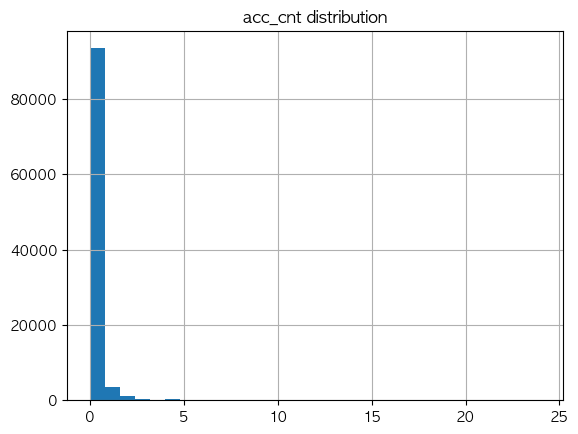

In [80]:
import matplotlib.pyplot as plt

model_df_clean["acc_cnt"].hist(bins=30)
plt.title("acc_cnt distribution")
plt.show()

In [81]:
model_df_clean.groupby("city")["acc_cnt"].agg(["sum", "mean", "var", "max", "count"])

,sum,mean,var,max,count
city,,,,,
경기도 성남시,3568,0.245849,0.968358,24,14513
경기도 하남시,1236,0.128898,0.428106,15,9589
경기도 화성시,3696,0.051621,0.137004,15,71599
서울특별시 송파구,2434,0.706531,2.749798,20,3445


In [82]:
# cluster 분포 확인
model_df_clean["cluster"].value_counts()

cluster
neutral    93252
hotspot     5894
Name: count, dtype: int64

In [85]:
# 도시별 cluster 분포 확인
pd.crosstab(model_df_clean["city"], model_df_clean["cluster"])

cluster,hotspot,neutral
city,,
경기도 성남시,1258,13255
경기도 하남시,585,9004
경기도 화성시,3723,67876
서울특별시 송파구,328,3117


In [86]:
# 도시별 비율
pd.crosstab(
    model_df_clean["city"],
    model_df_clean["cluster"],
    normalize="index"
)

cluster,hotspot,neutral
city,,
경기도 성남시,0.086681,0.913319
경기도 하남시,0.061007,0.938993
경기도 화성시,0.051998,0.948002
서울특별시 송파구,0.095210,0.904790


- 위례, 판교 -> hotspot 밀도 높음
    - 도심형 교통 구조
- 동탄 -> hotspot 밀도 낮음
    - 신도시 + 분산형 구조
-> 도시 구조 차이가 사고 집중도에 영향을 끼칠 수 있음

In [87]:
# hotspot vs non-hotspot 평균 비교
cols = [
"resident_pop","flow_pop","working_pop","visit_pop","service_pop",
"traffic_volume","mean_speed","congestion_freq","congestion_time",
"crosswalk_count","bus_stop_count","school_count","kinder_count",
"daycare_count","cctv_count","speedbump_count"
]

model_df_clean.groupby("cluster")[cols].mean().round(2)

,resident_pop,flow_pop,working_pop,visit_pop,service_pop,traffic_volume,mean_speed,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
cluster,,,,,,,,,,,,,,,,
hotspot,16.92,13.38,3.88,9.5,1.11,498.45,27.26,47.77,59.11,0.60,0.31,0.01,0.01,0.08,0.11,0.12
neutral,1.60,1.06,0.36,0.7,0.09,116.86,10.10,11.61,14.56,0.07,0.05,0.00,0.00,0.01,0.01,0.04


1. 거주인구
- hotspot: 16.9
- neutral: 1.6

2. 유동인구
- hotspot: 13.3
- neutral: 1.0

3. 교통량
- hotspot: 498
- neutral: 116

4. 평균속도
- hotspot: 27
- neutral: 10

5. 교차로
- hotspot: 0.6
- nuetral: 0.07

6. 버스정류장
- hotspot: 0.31
- neutral: 0.05

-> 핫스팟은 사람과 교통이 집중된 공간에서 발생

In [88]:
# 도시별 hotspot vs neutral 비교
model_df_clean.groupby(["city","cluster"])[cols].mean().round(2)

resident_pop  flow_pop  working_pop  visit_pop  \
city      cluster                                                   
경기도 성남시   hotspot          7.23     24.85         7.17      17.68   
          neutral          2.53      2.19         0.69       1.50   
경기도 하남시   hotspot         29.28     14.19         3.18      11.01   
          neutral          3.79      1.04         0.25       0.79   
경기도 화성시   hotspot         19.74      6.58         2.05       4.53   
          neutral          0.99      0.46         0.21       0.26   
서울특별시 송파구 hotspot          0.00     45.17        13.31      31.87   
          neutral          4.49      9.31         2.67       6.64   

                   service_pop  traffic_volume  mean_speed  congestion_freq  \
city      cluster                                                             
경기도 성남시   hotspot         2.07          691.17       28.16            51.79   
          neutral         0.18          241.41       13.06            18.74   
경기도 하남시   hotspot         1.18          660.23       25.70            47.19   
          neutral         0.09          148.09        7.85            11.12   
경기도 화성시   hotspot         0.55          391.46       27.33            46.02   
          neutral         0.04           76.91        9.51             9.50   
서울특별시 송파구 hotspot         3.77          685.10       25.87            53.23   
          neutral         0.78          367.01       16.94            28.81   

                   congestion_time  crosswalk_count  bus_stop_count  \
city      cluster                                                     
경기도 성남시   hotspot            63.57             0.18            0.43   
          neutral            22.75             0.03            0.09   
경기도 하남시   hotspot            58.62             0.87            0.38   
          neutral            13.34             0.08            0.05   
경기도 화성시   hotspot            57.04             0.64            0.24   
          neutral            12.12             0.05            0.03   
서울특별시 송파구 hotspot            66.33             1.32            0.62   
          neutral            36.55             0.57            0.19   

                   school_count  kinder_count  daycare_count  cctv_count  \
city      cluster                                                          
경기도 성남시   hotspot          0.01          0.01           0.08        0.15   
          neutral          0.01          0.01           0.03        0.01   
경기도 하남시   hotspot          0.01          0.01           0.07        0.23   
          neutral          0.01          0.00           0.02        0.02   
경기도 화성시   hotspot          0.02          0.01           0.09        0.08   
          neutral          0.00          0.00           0.01        0.01   
서울특별시 송파구 hotspot          0.01          0.01           0.05        0.12   
          neutral          0.03          0.01           0.10        0.10   

                   speedbump_count  
city      cluster                   
경기도 성남시   hotspot             0.34  
          neutral             0.13  
경기도 하남시   hotspot             0.22  
          neutral             0.04  
경기도 화성시   hotspot             0.00  
          neutral             0.00  
서울특별시 송파구 hotspot             0.51  
          neutral             0.47

In [89]:
# landuse 비교
pd.crosstab(
    model_df_clean["cluster"],
    model_df_clean["landuse_group"],
    normalize="index"
)

landuse_group,commercial,green,other,public,residential,road
cluster,,,,,,
hotspot,0.045131,0.046488,0.695792,0.013234,0.089413,0.109942
neutral,0.003861,0.017126,0.955711,0.002241,0.014166,0.006895


1. hotspot
- commercial: 4.5%
- road: 10.9%
- residential: 8.9%

2. neutral
- commercial: 0.38%
- road: 0.68

-> 핫스팟은 도로, 상업지역, 주거지역에서 많이 발생


In [90]:
# 도시별 landuse hotspot 구조
pd.crosstab(
    [model_df_clean["city"], model_df_clean["cluster"]],
    model_df_clean["landuse_group"],
    normalize="index"
)

landuse_group      commercial     green     other    public  residential  \
city      cluster                                                          
경기도 성남시   hotspot    0.024642  0.023052  0.839428  0.005564     0.038951   
          neutral    0.004527  0.034553  0.916107  0.005507     0.022558   
경기도 하남시   hotspot    0.100855  0.070085  0.584615  0.017094     0.085470   
          neutral    0.006664  0.017992  0.937805  0.004331     0.024100   
경기도 화성시   hotspot    0.046468  0.054795  0.640075  0.016385     0.114961   
          neutral    0.003064  0.013466  0.967426  0.001282     0.010534   
서울특별시 송파구 hotspot    0.009146  0.000000  0.975610  0.000000     0.000000   
          neutral    0.010266  0.020212  0.920757  0.003208     0.028874   

landuse_group          road  
city      cluster            
경기도 성남시   hotspot  0.068362  
          neutral  0.016748  
경기도 하남시   hotspot  0.141880  
          neutral  0.009107  
경기도 화성시   hotspot  0.127317  
          neutral  0.004228  
서울특별시 송파구 hotspot  0.015244  
          neutral  0.016683

In [91]:
# hotspot 사고 집중도 확인
model_df_clean.groupby("cluster")["acc_cnt"].agg(["sum","mean","count"])

,sum,mean,count
cluster,,,
hotspot,6724,1.140821,5894
neutral,4210,0.045146,93252


1. hotspot
- 평균 사고: 1.14

2. neutral
- 평균 사고: 0.045

-> 약 25배 차이
-> 공간 클러스터링이 제대로 되었다는 걸 확인 가능

In [92]:
# 도시별 hotspot 사고 집중도
model_df_clean.groupby(["city","cluster"])["acc_cnt"].agg(["sum","mean","count"])

sum      mean  count
city      cluster                       
경기도 성남시   hotspot  2243  1.782989   1258
          neutral  1325  0.099962  13255
경기도 하남시   hotspot   804  1.374359    585
          neutral   432  0.047979   9004
경기도 화성시   hotspot  2637  0.708300   3723
          neutral  1059  0.015602  67876
서울특별시 송파구 hotspot  1040  3.170732    328
          neutral  1394  0.447225   3117

In [93]:
# 상관관계 확인

corr_cols = [
"resident_pop","flow_pop","working_pop","visit_pop","service_pop",
"traffic_volume","mean_speed","congestion_freq",
"crosswalk_count","bus_stop_count","school_count",
"cctv_count","speedbump_count"
]

model_df_clean[corr_cols].corr()

,resident_pop,flow_pop,working_pop,visit_pop,service_pop,traffic_volume,mean_speed,congestion_freq,crosswalk_count,bus_stop_count,school_count,cctv_count,speedbump_count
resident_pop,1.000000,0.090239,0.054136,0.102163,0.090074,0.031264,0.024743,0.098445,0.078619,0.048263,0.000878,0.029824,-0.004366
flow_pop,0.090239,1.000000,0.910935,0.979213,0.999798,0.144540,0.115279,0.267158,0.243780,0.216182,0.027053,0.127373,0.109510
working_pop,0.054136,0.910935,1.000000,0.808319,0.910596,0.117871,0.102274,0.241887,0.207764,0.182259,0.016916,0.104346,0.079485
visit_pop,0.102163,0.979213,0.808319,1.000000,0.979090,0.148318,0.114229,0.262331,0.245744,0.218901,0.030290,0.130469,0.117200
service_pop,0.090074,0.999798,0.910596,0.979090,1.000000,0.144550,0.115275,0.267185,0.243770,0.216442,0.027234,0.127430,0.109632
traffic_volume,0.031264,0.144540,0.117871,0.148318,0.144550,1.000000,0.727332,0.526524,0.097762,0.134098,0.006455,0.074277,0.040639
mean_speed,0.024743,0.115279,0.102274,0.114229,0.115275,0.727332,1.000000,0.645953,0.143590,0.186101,0.006954,0.082965,0.043639
congestion_freq,0.098445,0.267158,0.241887,0.262331,0.267185,0.526524,0.645953,1.000000,0.289945,0.259294,0.055512,0.125276,0.131582
crosswalk_count,0.078619,0.243780,0.207764,0.245744,0.243770,0.097762,0.143590,0.289945,1.000000,0.206630,0.046760,0.143035,0.082888
bus_stop_count,0.048263,0.216182,0.182259,0.218901,0.216442,0.134098,0.186101,0.259294,0.206630,1.000000,0.006185,0.096704,0.073622


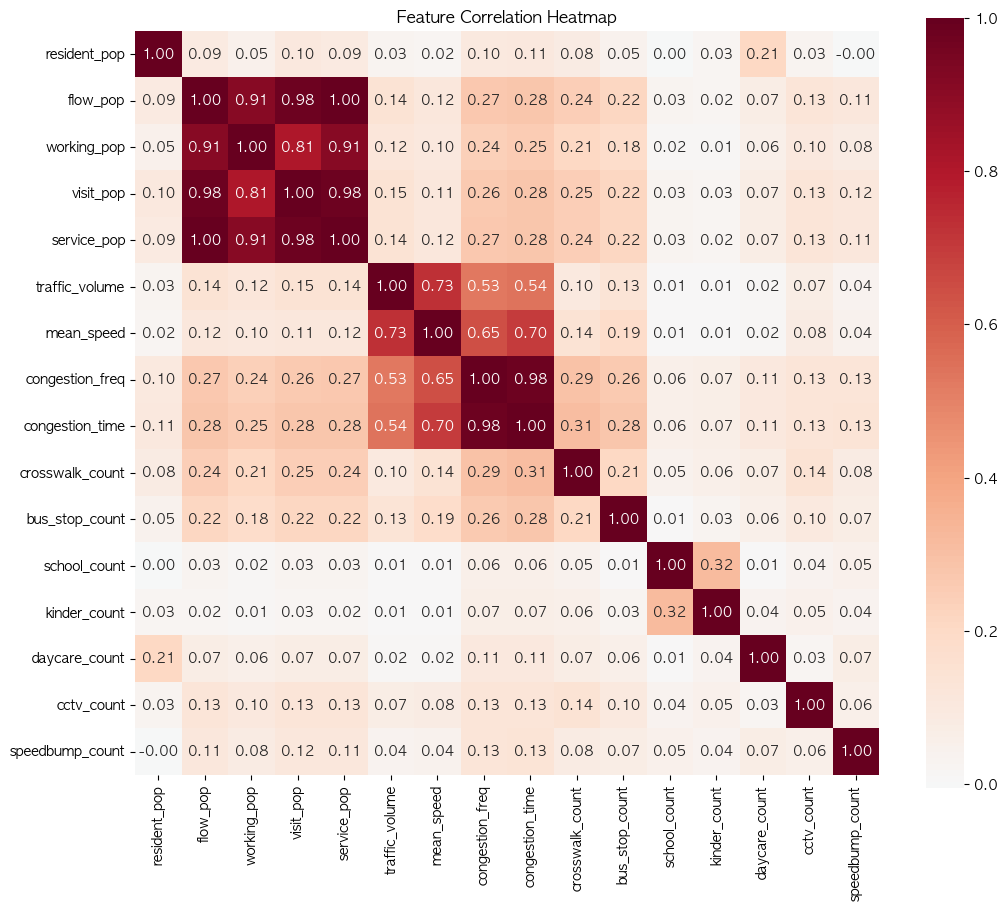

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
"resident_pop","flow_pop","working_pop","visit_pop","service_pop",
"traffic_volume","mean_speed","congestion_freq","congestion_time",
"crosswalk_count","bus_stop_count","school_count","kinder_count",
"daycare_count","cctv_count","speedbump_count"
]

corr_matrix = model_df_clean[corr_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.show()

- 유동인구 변수 간에 다중공선성 매우 높음
- 교통 변수들도 상관관계 높음

### 통계적 검정

In [ ]:
# 전체 hotspot vs neutral 검정
from scipy.stats import mannwhitneyu
import pandas as pd

cols = [
"resident_pop","flow_pop","working_pop","visit_pop","service_pop",
"traffic_volume","mean_speed","congestion_freq","congestion_time",
"crosswalk_count","bus_stop_count","school_count","kinder_count",
"daycare_count","cctv_count","speedbump_count"
]

hotspot = model_df_clean[model_df_clean["cluster"]=="hotspot"]
neutral = model_df_clean[model_df_clean["cluster"]=="neutral"]

results = []

for col in cols:
    
    stat, p = mannwhitneyu(
        hotspot[col],
        neutral[col],
        alternative="two-sided"
    )
    
    results.append({
        "variable": col,
        "hotspot_mean": hotspot[col].mean(),
        "neutral_mean": neutral[col].mean(),
        "p_value": p
    })

mw_result = pd.DataFrame(results).sort_values("p_value")

mw_result

,variable,hotspot_mean,neutral_mean,p_value
0,resident_pop,16.915436,1.598870,0.000000e+00
1,flow_pop,13.382699,1.060103,0.000000e+00
2,working_pop,3.879729,0.361599,0.000000e+00
3,visit_pop,9.502971,0.698504,0.000000e+00
4,service_pop,1.114422,0.086846,0.000000e+00
5,traffic_volume,498.447095,116.862267,0.000000e+00
6,mean_speed,27.264978,10.102246,0.000000e+00
7,congestion_freq,47.768399,11.614016,0.000000e+00
8,congestion_time,59.109508,14.564631,0.000000e+00
9,crosswalk_count,0.601120,0.065747,0.000000e+00


- 0이 매우 많고 왜도가 심한 분포라 비모수 검정으로 진행


In [96]:
# 도시별 hotspot vs non-hotspot 검정
city_results = []

for city in model_df_clean["city"].unique():
    
    city_df = model_df_clean[model_df_clean["city"] == city]
    
    hotspot = city_df[city_df["cluster"]=="hotspot"]
    neutral = city_df[city_df["cluster"]=="neutral"]
    
    for col in cols:
        
        stat, p = mannwhitneyu(
            hotspot[col],
            neutral[col],
            alternative="two-sided"
        )
        
        city_results.append({
            "city": city,
            "variable": col,
            "p_value": p
        })

city_test = pd.DataFrame(city_results)

city_test.sort_values(["variable","city"])

,city,variable,p_value
26,경기도 성남시,bus_stop_count,1.096379e-138
58,경기도 하남시,bus_stop_count,1.692870e-105
10,경기도 화성시,bus_stop_count,0.000000e+00
42,서울특별시 송파구,bus_stop_count,3.190715e-29
30,경기도 성남시,cctv_count,1.975444e-149
...,...,...,...
35,서울특별시 송파구,visit_pop,5.936819e-95
18,경기도 성남시,working_pop,0.000000e+00
50,경기도 하남시,working_pop,5.194852e-242
2,경기도 화성시,working_pop,0.000000e+00


In [97]:
city_test.pivot(
    index="variable",
    columns="city",
    values="p_value"
)

city,경기도 성남시,경기도 하남시,경기도 화성시,서울특별시 송파구
variable,,,,
bus_stop_count,1.096379e-138,1.692870e-105,0.000000e+00,3.190715e-29
cctv_count,1.975444e-149,3.057630e-128,1.299191e-110,1.122706e-01
congestion_freq,3.606507e-274,7.431553e-237,0.000000e+00,1.863751e-34
congestion_time,6.549425e-283,5.704157e-241,0.000000e+00,3.983412e-35
crosswalk_count,4.637909e-91,6.598827e-209,0.000000e+00,1.609214e-30
daycare_count,4.268214e-21,5.096988e-12,0.000000e+00,3.431793e-02
flow_pop,0.000000e+00,2.339680e-258,0.000000e+00,1.302851e-95
kinder_count,2.449308e-01,2.084058e-01,3.530362e-60,9.221914e-01
mean_speed,1.228474e-224,1.157513e-211,0.000000e+00,6.921093e-24


**결과 해석**
1. 모든 도시에서 유의한 변수
- traffic_volume, mean_speed, congestion_freq, congestion_time\
-> 교통량과 교통 흐름 변수는 모든 도시에서 핫스팟 형성에 유의한 영향을 미침
<br>

- flow_pop, visit_pop, working_pop\
-> 유동 인구 데이터는 모든 도시에서 핫스팟 형성에 유의한 영향을 미침
<br>
- bus_stpo_count
- crosswalk_count\
-> 교통시설 주변에 교통사고가 집중되는 경향 존재 

2. 도시별로 다른 변수
- kinder_count, school_count
- 판교, 하남미사, 위례(kinder_count는 유의)에서 유의하지 않음\
-> 교육시설의 위치는 교통사고에 영향을 주지 않는다(흠)
<br>

- speedbump_count
- 동탄, 위례에서 유의하지 않음
<br>

- cctv_count
- 위례에서 유의하지 않음


In [98]:
model_df_clean.columns

Index(['gid', 'city', 'geometry', 'acc_cnt', 'acc_binary', 'resident_pop',
       'flow_pop', 'working_pop', 'visit_pop', 'service_pop', 'mean_speed',
       'traffic_volume', 'congestion_freq', 'congestion_time',
       'crosswalk_count', 'bus_stop_count', 'school_count', 'kinder_count',
       'daycare_count', 'cctv_count', 'speedbump_count', 'blockType_main',
       'landuse_group', 'is_residential', 'is_commercial', 'is_green',
       'is_road', 'is_public', 'cluster', 'Gi_star_z', 'Gi_class'],
      dtype='object')

### 취약계층 사고 분석
- 없어서 데이터 가져와서 붙일 거긔

In [101]:
child_acc = accident[accident["age_group"] == "12세 이하"].copy()
elder_acc = accident[accident["age_group"] == "65세 이상"].copy()

child_join = gpd.sjoin(
    child_acc,
    grid_4_clean[["gid", "geometry"]],
    how="left",
    predicate="within"
)

elder_join = gpd.sjoin(
    elder_acc,
    grid_4_clean[["gid", "geometry"]],
    how="left",
    predicate="within"
)

In [102]:
print("child 매핑 안 된 사고 수:", child_join["gid"].isna().sum())
print("elder 매핑 안 된 사고 수:", elder_join["gid"].isna().sum())

child 매핑 안 된 사고 수: 0
elder 매핑 안 된 사고 수: 2


In [103]:
child_acc = child_acc.reset_index(drop=True).copy()
child_acc["acc_id"] = child_acc.index

elder_acc = elder_acc.reset_index(drop=True).copy()
elder_acc["acc_id"] = elder_acc.index

child_join = gpd.sjoin(
    child_acc,
    grid_4_clean[["gid", "geometry"]],
    how="left",
    predicate="within"
)

elder_join = gpd.sjoin(
    elder_acc,
    grid_4_clean[["gid", "geometry"]],
    how="left",
    predicate="within"
)

child_dup = child_join.groupby("acc_id").size()
elder_dup = elder_join.groupby("acc_id").size()

print("child 2개 이상 격자에 매핑된 사고 수:", (child_dup > 1).sum())
print("elder 2개 이상 격자에 매핑된 사고 수:", (elder_dup > 1).sum())

child 2개 이상 격자에 매핑된 사고 수: 0
elder 2개 이상 격자에 매핑된 사고 수: 0


In [108]:
# 모델링 데이터셋에 어린이/노인 사고 건수 컬럼 추가

child_cnt = child_join.groupby("gid").size().reset_index(name="child_acc_cnt")
elder_cnt = elder_join.groupby("gid").size().reset_index(name="elder_acc_cnt")

model_df_clean = model_df_clean.merge(child_cnt, on="gid", how="left")
model_df_clean = model_df_clean.merge(elder_cnt, on="gid", how="left")

model_df_clean["child_acc_cnt"] = model_df_clean["child_acc_cnt"].fillna(0)
model_df_clean["elder_acc_cnt"] = model_df_clean["elder_acc_cnt"].fillna(0)

model_df_clean["vulnerable_acc_cnt"] = (
    model_df_clean["child_acc_cnt"] +
    model_df_clean["elder_acc_cnt"]
)

model_df_clean[[
"child_acc_cnt",
"elder_acc_cnt",
"vulnerable_acc_cnt"
]].describe()

,child_acc_cnt,elder_acc_cnt,vulnerable_acc_cnt
count,99146.000000,99146.000000,99146.000000
mean,0.002138,0.013122,0.015260
std,0.047271,0.133611,0.144351
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,2.000000,6.000000,6.000000


In [111]:
# 어린이/노인 hotspot 생성

gdf_model = grid_4_clean[["gid","geometry"]].merge(
    model_df_clean,
    on="gid",
    how="left"
)

gdf_model.head()

,gid,geometry_x,city,geometry_y,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,...,is_commercial,is_green,is_road,is_public,cluster,Gi_star_z,Gi_class,child_acc_cnt,elder_acc_cnt,vulnerable_acc_cnt
0,다사581304,"POLYGON ((958100 1930400, 958100 1930500, 9582...",경기도 성남시,POLYGON ((127.02677465735422 37.37172194466841...,0,0,0.0,0.000000,0.000000,0.000000,...,0,0,0,0,neutral,-0.499977,Not Significant,0.0,0.0,0.0
1,다사581305,"POLYGON ((958100 1930500, 958100 1930600, 9582...",경기도 성남시,POLYGON ((127.02676899519032 37.37262330005522...,0,0,0.0,0.031594,0.015572,0.016022,...,0,0,0,0,neutral,-0.612386,Not Significant,0.0,0.0,0.0
2,다사581306,"POLYGON ((958100 1930600, 958100 1930700, 9582...",경기도 성남시,POLYGON ((127.02676333277432 37.37352465530359...,0,0,0.0,0.000000,0.000000,0.000000,...,0,0,0,0,neutral,-0.559010,Not Significant,0.0,0.0,0.0
3,다사582304,"POLYGON ((958200 1930400, 958200 1930500, 9583...",경기도 성남시,POLYGON ((127.02790403835982 37.37172645813172...,0,0,0.0,0.022768,0.018269,0.004499,...,0,0,0,0,neutral,-0.612386,Not Significant,0.0,0.0,0.0
4,다사582305,"POLYGON ((958200 1930500, 958200 1930600, 9583...",경기도 성남시,POLYGON ((127.02789838970781 37.37262781366482...,0,0,0.0,0.031655,0.016485,0.015169,...,0,0,0,0,neutral,-0.750095,Not Significant,0.0,0.0,0.0


In [120]:
# 어린이 hotspot

child_gi_list = []

for city in sorted(gdf_model["city"].dropna().unique()):

    city_gdf = gdf_model[gdf_model["city"] == city].copy().reset_index(drop=True)

    # 어린이 사고 없는 도시는 skip
    if city_gdf["child_acc_cnt"].sum() == 0:
        continue

    neighbors = make_queen_neighbors(city_gdf)

    city_gdf["child_gi_z"] = compute_gi_star(
        city_gdf,
        neighbors,
        value_col="child_acc_cnt"
    )

    city_gdf["child_hotspot"] = "neutral"
    city_gdf.loc[city_gdf["child_gi_z"] > 1.96, "child_hotspot"] = "hotspot"
    city_gdf.loc[city_gdf["child_gi_z"] < -1.96, "child_hotspot"] = "coldspot"

    child_gi_list.append(city_gdf)

gdf_child = pd.concat(child_gi_list, ignore_index=True)

In [121]:
gdf_child["child_hotspot"].value_counts()

child_hotspot
neutral    97470
hotspot     1676
Name: count, dtype: int64

In [122]:
# 노인 hotspot

elder_gi_list = []

for city in sorted(gdf_model["city"].dropna().unique()):

    city_gdf = gdf_model[gdf_model["city"] == city].copy().reset_index(drop=True)

    if city_gdf["elder_acc_cnt"].sum() == 0:
        continue

    neighbors = make_queen_neighbors(city_gdf)

    city_gdf["elder_gi_z"] = compute_gi_star(
        city_gdf,
        neighbors,
        value_col="elder_acc_cnt"
    )

    city_gdf["elder_hotspot"] = "neutral"
    city_gdf.loc[city_gdf["elder_gi_z"] > 1.96, "elder_hotspot"] = "hotspot"
    city_gdf.loc[city_gdf["elder_gi_z"] < -1.96, "elder_hotspot"] = "coldspot"

    elder_gi_list.append(city_gdf)

gdf_elder = pd.concat(elder_gi_list, ignore_index=True)

gdf_elder["elder_hotspot"].value_counts()

elder_hotspot
neutral    95362
hotspot     3784
Name: count, dtype: int64

In [ ]:
gdf_hotspot = gdf_child.merge(
    gdf_elder[["gid","elder_hotspot","elder_gi_z"]],
    on="gid",
    how="left"
)

In [125]:
# 방금 만든 elder 결과(y)만 남기고 정리
gdf_hotspot = gdf_hotspot.drop(
    columns=["elder_hotspot_x", "elder_gi_z_x"],
    errors="ignore"
)

gdf_hotspot = gdf_hotspot.rename(columns={
    "elder_hotspot_y": "elder_hotspot",
    "elder_gi_z_y": "elder_gi_z"
})

# 확인
gdf_hotspot.columns

# 비교용 컬럼 다시 만들기
gdf_hotspot["hotspot_compare"] = "none"

gdf_hotspot.loc[
    (gdf_hotspot["child_hotspot"] == "hotspot") &
    (gdf_hotspot["elder_hotspot"] == "hotspot"),
    "hotspot_compare"
] = "both"

gdf_hotspot.loc[
    (gdf_hotspot["child_hotspot"] == "hotspot") &
    (gdf_hotspot["elder_hotspot"] != "hotspot"),
    "hotspot_compare"
] = "child_only"

gdf_hotspot.loc[
    (gdf_hotspot["child_hotspot"] != "hotspot") &
    (gdf_hotspot["elder_hotspot"] == "hotspot"),
    "hotspot_compare"
] = "elder_only"

gdf_hotspot[["child_hotspot", "elder_hotspot", "hotspot_compare"]].head()

,child_hotspot,elder_hotspot,hotspot_compare
0,neutral,neutral,none
1,neutral,neutral,none
2,neutral,neutral,none
3,neutral,neutral,none
4,neutral,neutral,none


In [127]:
pd.crosstab(
    gdf_model["child_hotspot"],
    gdf_model["elder_hotspot"]
)

elder_hotspot,hotspot,neutral
child_hotspot,,
hotspot,710,975
neutral,6654,90807


/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/2811229941.py:45: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Hotspot Type")
/var/folders/z1/1hkj2_y90qv61x60jcxtsqhr0000gn/T/ipykernel_49935/2811229941.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Hotspot Type")


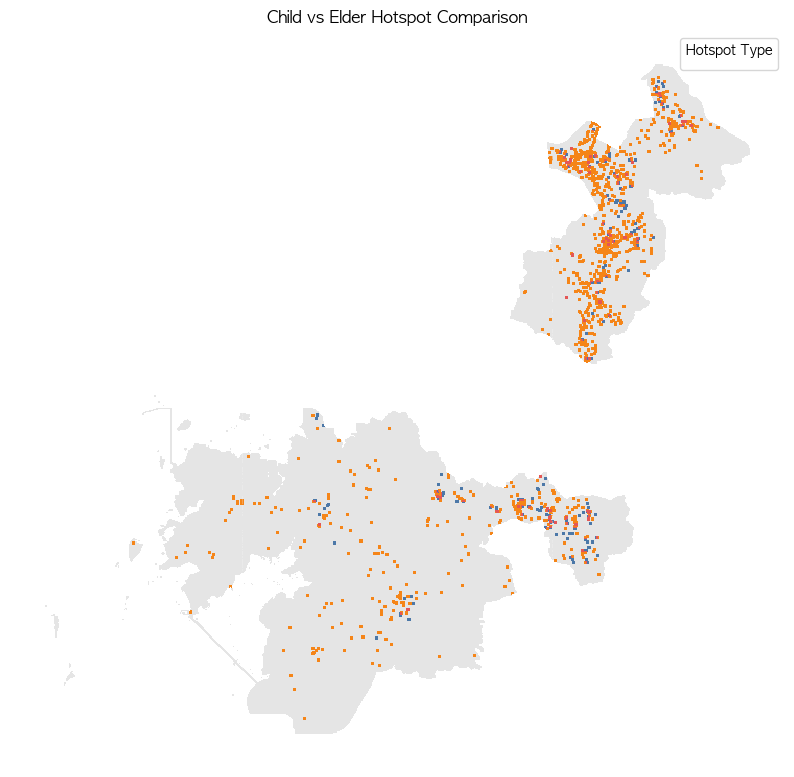

In [128]:
# 어린이/노인 hotspot 한 번에 보기

gdf_model["hotspot_compare"] = "none"

gdf_model.loc[
    (gdf_model["child_hotspot"] == "hotspot") &
    (gdf_model["elder_hotspot"] == "hotspot"),
    "hotspot_compare"
] = "both"

gdf_model.loc[
    (gdf_model["child_hotspot"] == "hotspot") &
    (gdf_model["elder_hotspot"] != "hotspot"),
    "hotspot_compare"
] = "child_only"

gdf_model.loc[
    (gdf_model["child_hotspot"] != "hotspot") &
    (gdf_model["elder_hotspot"] == "hotspot"),
    "hotspot_compare"
] = "elder_only"

gdf_model["hotspot_compare"].value_counts()

import matplotlib.pyplot as plt

color_map = {
    "none": "#e5e5e5",
    "child_only": "#4C78A8",
    "elder_only": "#F58518",
    "both": "#E45756"
}

fig, ax = plt.subplots(figsize=(10, 10))

for cat, color in color_map.items():
    gdf_model[gdf_model["hotspot_compare"] == cat].plot(
        ax=ax,
        color=color,
        edgecolor="none",
        label=cat
    )

ax.set_title("Child vs Elder Hotspot Comparison")
ax.legend(title="Hotspot Type")
ax.axis("off")
plt.show()


	•	빨강(both) → 어린이·노인 모두 위험
	•	파랑(child_only) → 어린이 특화 위험 구간
	•	주황(elder_only) → 노인 특화 위험 구간
	•	회색(none) → 둘 다 hotspot 아님

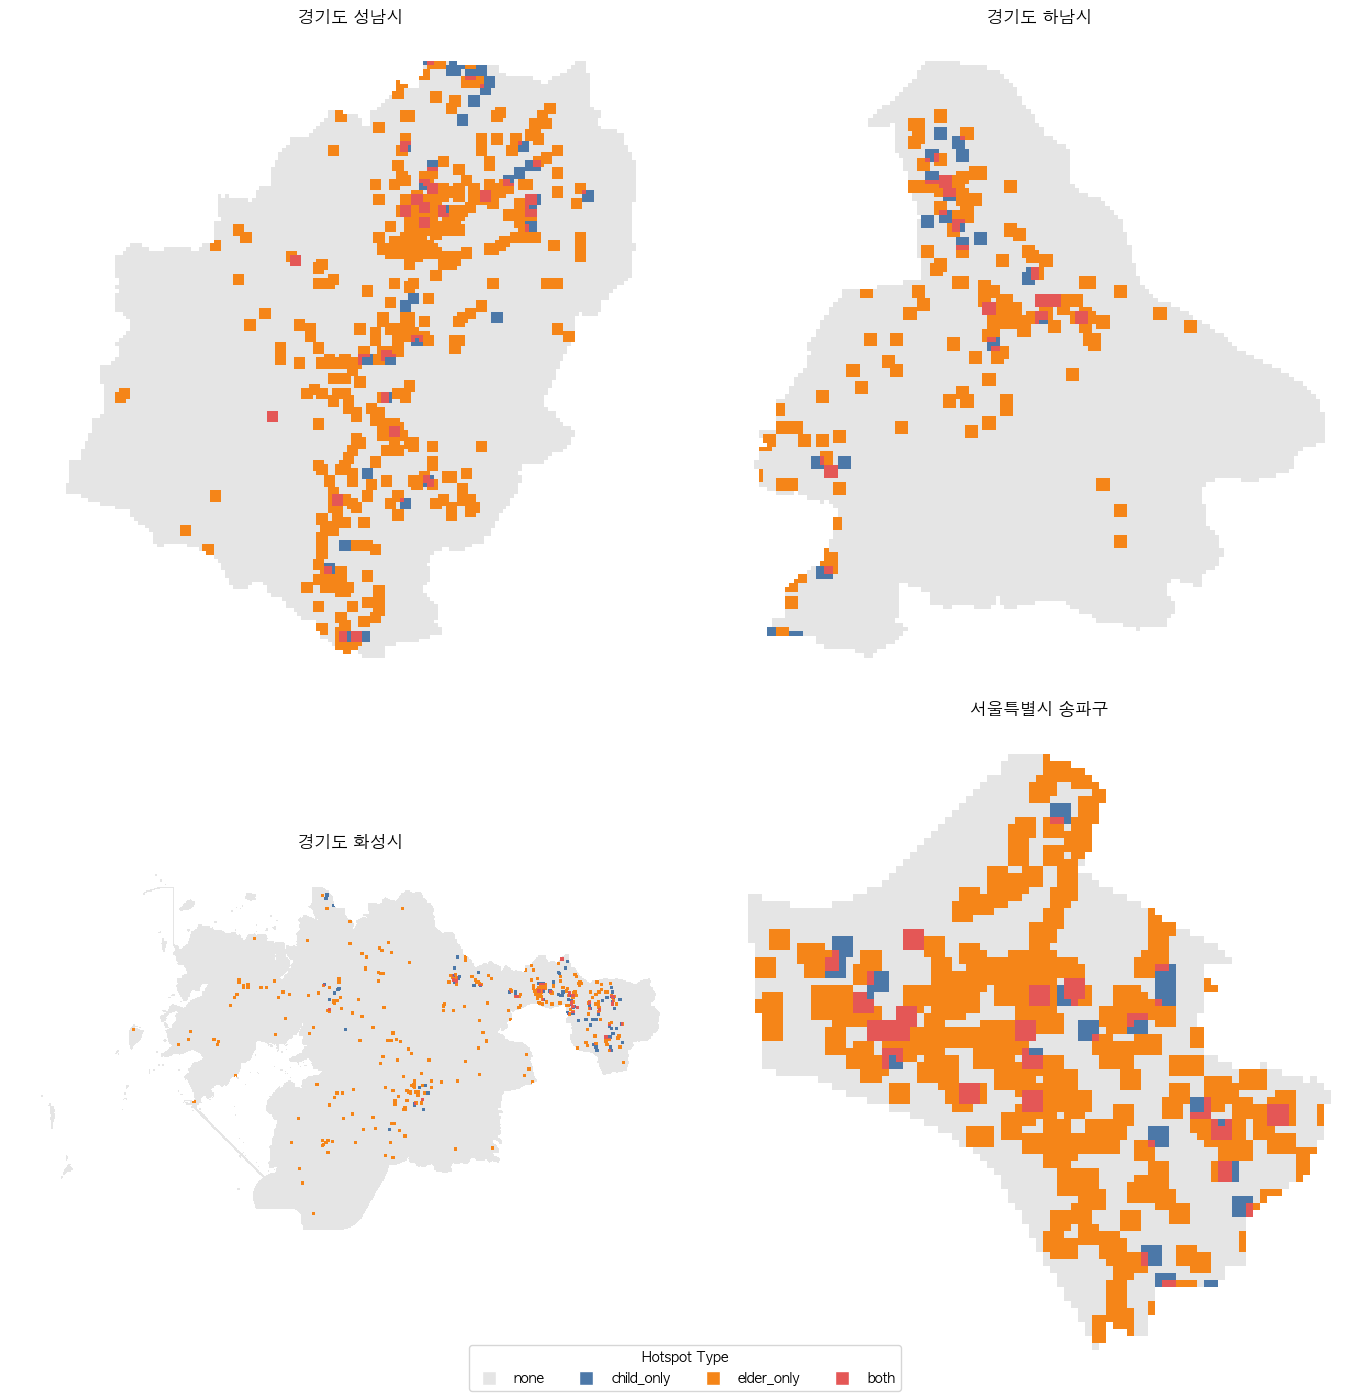

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

cities = gdf_model["city"].unique()

for ax, city in zip(axes, cities):
    city_gdf = gdf_model[gdf_model["city"] == city]
    
    for cat, color in color_map.items():
        city_gdf[city_gdf["hotspot_compare"] == cat].plot(
            ax=ax,
            color=color,
            edgecolor="none"
        )
    
    ax.set_title(city)
    ax.axis("off")

handles = [
    plt.Line2D([0], [0], marker='s', color='w', label=cat,
               markerfacecolor=color, markersize=10)
    for cat, color in color_map.items()
]

fig.legend(handles=handles, title="Hotspot Type", loc="lower center", ncol=4)
plt.tight_layout()
plt.show()

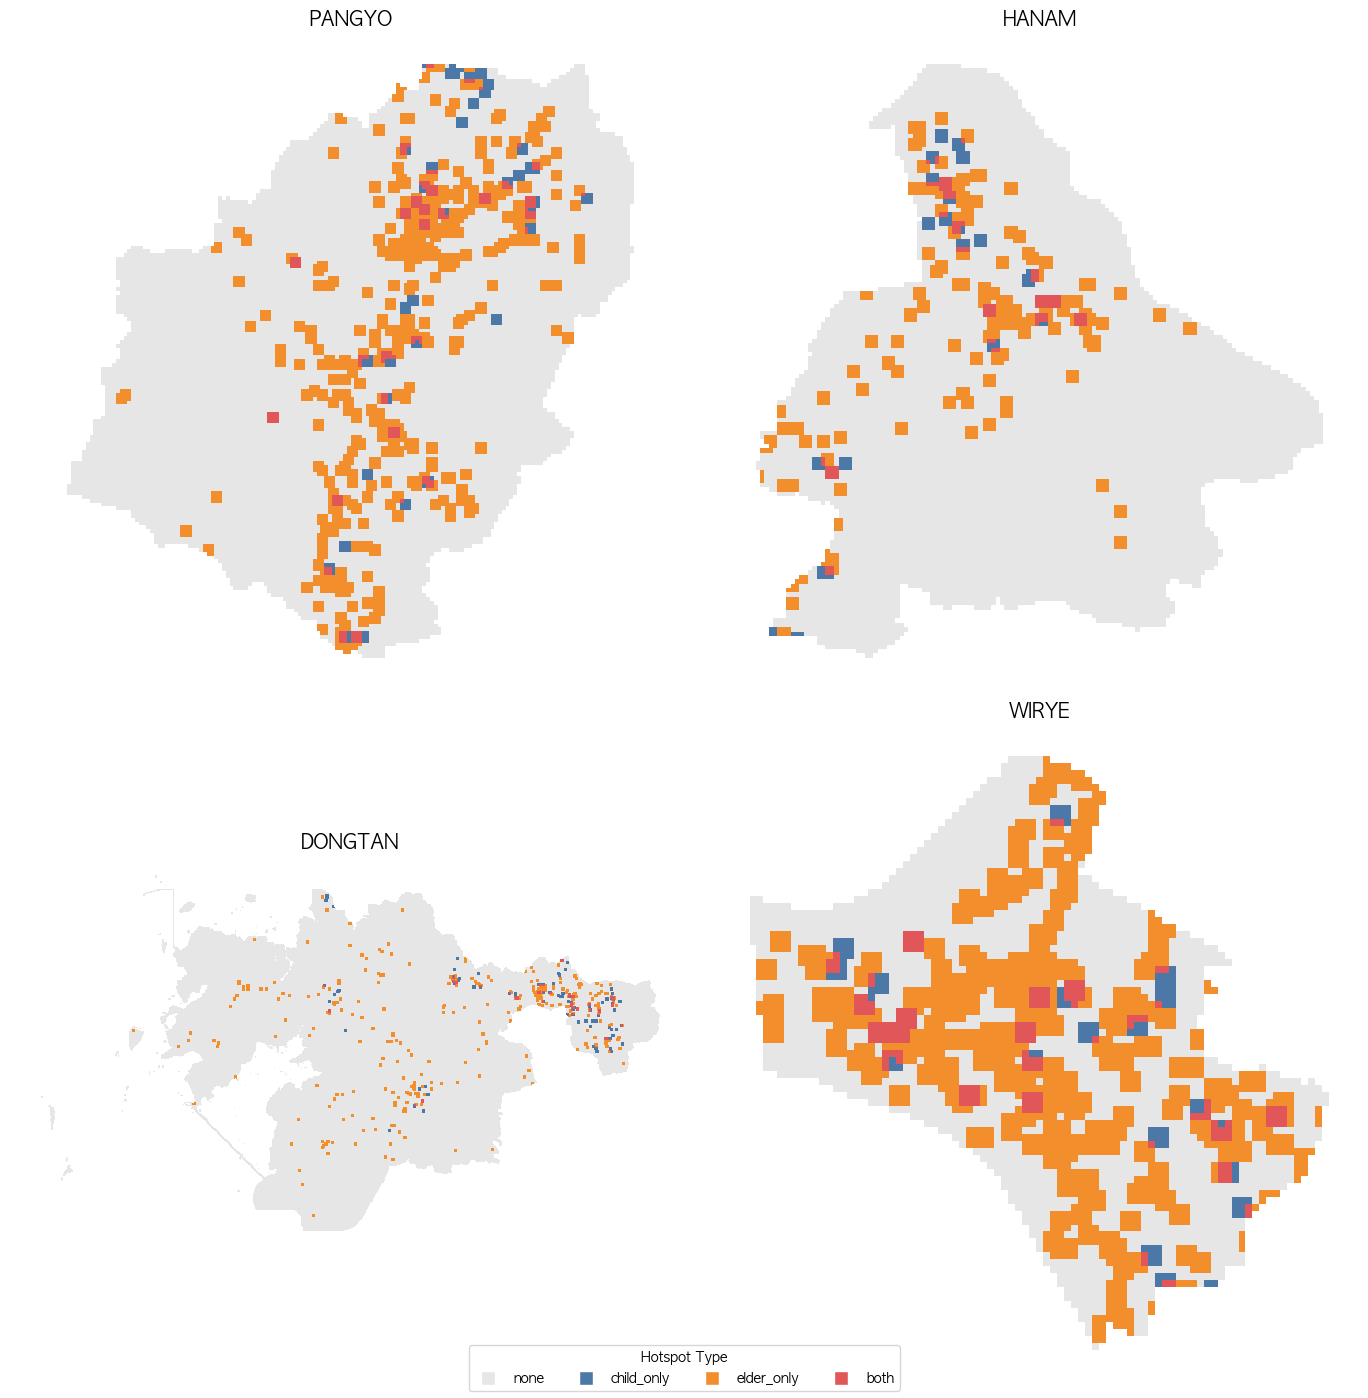

In [142]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

cities = gdf_model["city"].unique()

for ax, city in zip(axes, cities):
    city_gdf = gdf_model[gdf_model["city"] == city]
    
    for cat, color in color_map.items():
        city_gdf[city_gdf["hotspot_compare"] == cat].plot(
            ax=ax,
            color=color,
            edgecolor="none"
        )
    
    city_name_map = {
    "경기도 성남시": "PANGYO",
    "경기도 하남시": "HANAM",
    "경기도 화성시": "DONGTAN",
    "서울특별시 송파구": "WIRYE"
}

    ax.set_title(city_name_map.get(city, city), fontsize=14, fontweight="bold")
    ax.axis("off")

handles = [
    plt.Line2D([0], [0], marker='s', color='w', label=cat,
               markerfacecolor=color, markersize=10)
    for cat, color in color_map.items()
]

fig.legend(handles=handles, title="Hotspot Type", loc="lower center", ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
# 어린이 핫스팟 vs non-hotspot 비교
cols = [
"resident_pop",
"flow_pop",
"working_pop",
"visit_pop",
"traffic_volume",
"mean_speed",
"congestion_freq",
"congestion_time",
"crosswalk_count",
"bus_stop_count",
"school_count",
"kinder_count",
"daycare_count",
"cctv_count",
"speedbump_count"
]

gdf_child.groupby("child_hotspot")[cols].mean().round(2)

child_compare = (
    gdf_child
    .groupby("child_hotspot")[cols]
    .mean()
    .T
)

child_compare.round(2)

child_hotspot,hotspot,neutral
resident_pop,26.13,2.10
flow_pop,11.41,1.63
working_pop,2.82,0.53
visit_pop,8.58,1.10
traffic_volume,289.00,136.98
mean_speed,19.31,10.98
congestion_freq,46.40,13.20
congestion_time,57.18,16.53
crosswalk_count,0.70,0.09
bus_stop_count,0.31,0.06


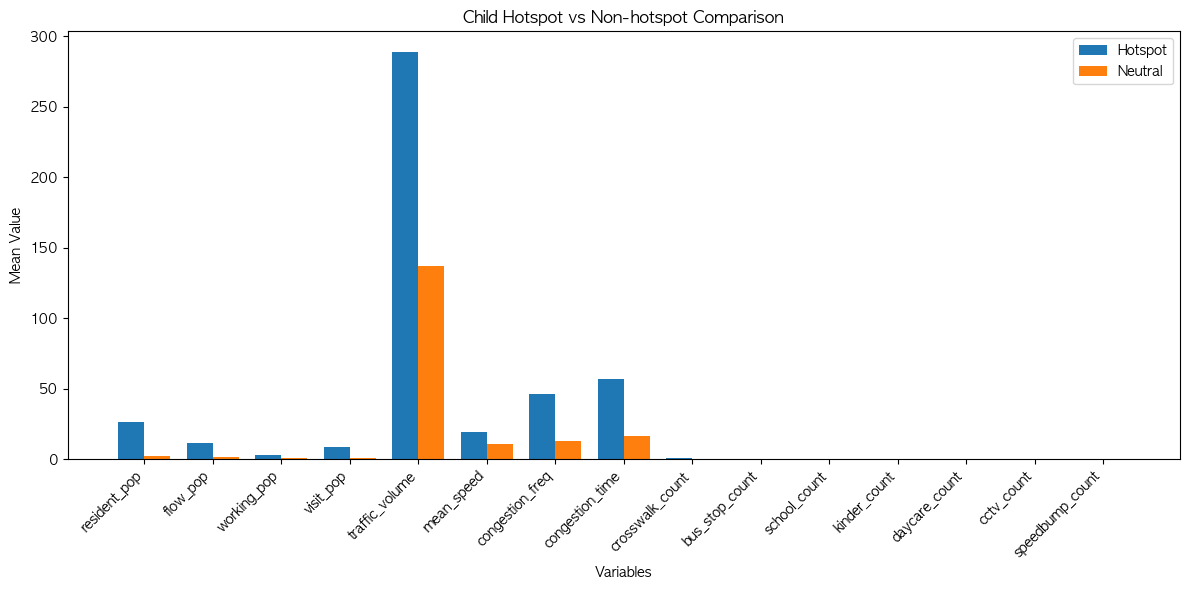

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# child_compare: index=variable, columns=['hotspot', 'neutral', 'diff'] 형태 가정
df_plot = child_compare.reset_index().rename(columns={"index": "variable"})

x = np.arange(len(df_plot))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df_plot["hotspot"], width=width, label="Hotspot")
plt.bar(x + width/2, df_plot["neutral"], width=width, label="Neutral")

plt.xticks(x, df_plot["variable"], rotation=45, ha="right")
plt.title("Child Hotspot vs Non-hotspot Comparison")
plt.xlabel("Variables")
plt.ylabel("Mean Value")
plt.legend()
plt.tight_layout()
plt.show()

In [143]:
child_compare["diff"] = child_compare["hotspot"] - child_compare["neutral"]
child_compare.sort_values("diff", ascending=False)

child_hotspot,hotspot,neutral,diff
traffic_volume,289.000235,136.976741,152.023495
congestion_time,57.183906,16.525415,40.658490
congestion_freq,46.397761,13.202160,33.195601
resident_pop,26.128566,2.103272,24.025294
flow_pop,11.406250,1.627346,9.778904
mean_speed,19.310267,10.981742,8.328525
visit_pop,8.581620,1.095359,7.486261
working_pop,2.824630,0.531988,2.292643
crosswalk_count,0.701074,0.087196,0.613878
bus_stop_count,0.306086,0.059854,0.246232


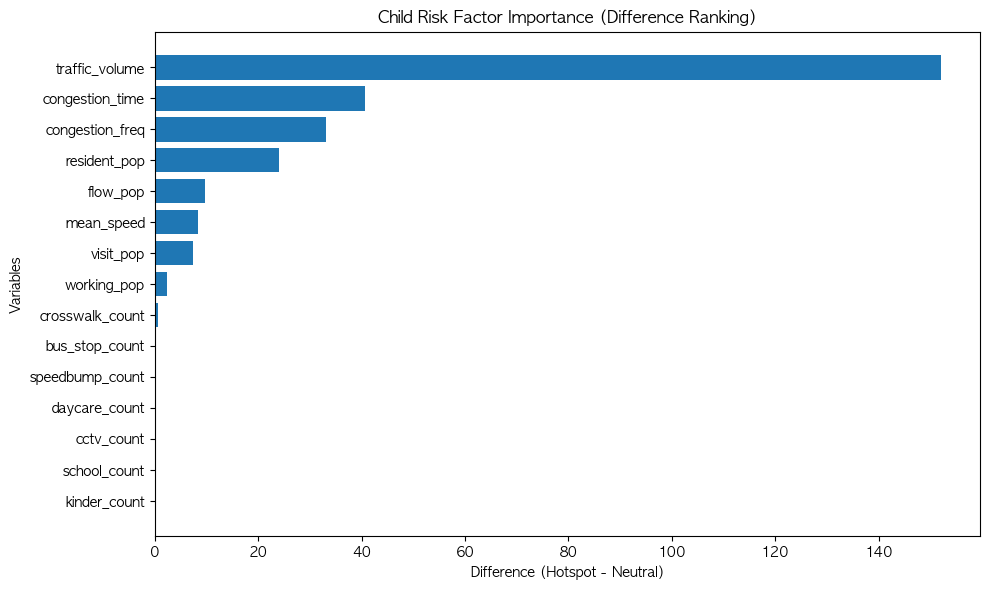

In [168]:
import matplotlib.pyplot as plt

df_diff = child_compare.sort_values("diff", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_diff.index, df_diff["diff"])

plt.title("Child Risk Factor Importance (Difference Ranking)")
plt.xlabel("Difference (Hotspot - Neutral)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [131]:
# 통계검정


results = []

for col in cols:

    hot = gdf_child[gdf_child["child_hotspot"] == "hotspot"][col]
    neutral = gdf_child[gdf_child["child_hotspot"] == "neutral"][col]

    stat, p = mannwhitneyu(hot, neutral)

    results.append({
        "variable": col,
        "hotspot_mean": hot.mean(),
        "neutral_mean": neutral.mean(),
        "p_value": p
    })

child_test = pd.DataFrame(results).sort_values("p_value")

child_test

,variable,hotspot_mean,neutral_mean,p_value
0,resident_pop,26.128566,2.103272,0.000000e+00
1,flow_pop,11.406250,1.627346,0.000000e+00
2,working_pop,2.824630,0.531988,0.000000e+00
3,visit_pop,8.581620,1.095359,0.000000e+00
4,traffic_volume,289.000235,136.976741,0.000000e+00
6,congestion_freq,46.397761,13.202160,0.000000e+00
7,congestion_time,57.183906,16.525415,0.000000e+00
8,crosswalk_count,0.701074,0.087196,0.000000e+00
12,daycare_count,0.158711,0.016056,0.000000e+00
5,mean_speed,19.310267,10.981742,6.555218e-229


- 어린이 hotspot 격자는 neutral 격자보다
	- 거주인구가 훨씬 많고
	- 유동인구 / 방문인구 / 직장인구도 높고
	- 교통량, 혼잡, 평균속도가 더 높고
	- 횡단보도, 버스정류장, 어린이집, 학교, 과속방지턱도 더 많음

- 즉 어린이 hotspot은 단순히 학교만 많은 곳이 아니라, 주거 + 생활이동 + 교통활동이 함께 큰 공간에서 형성


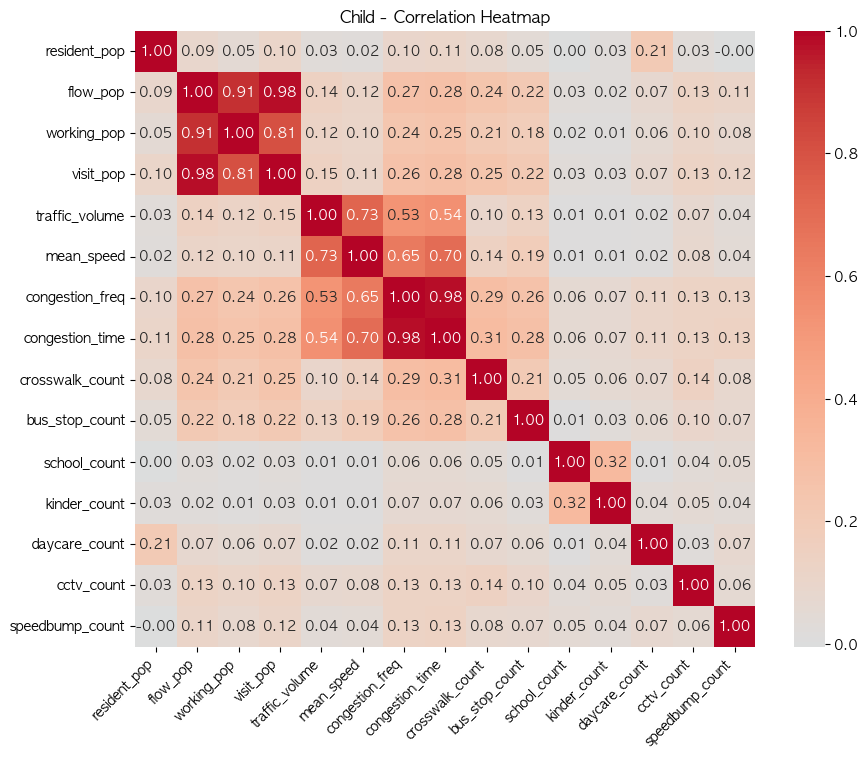

In [147]:
# 상관관계 히트맵
cols = [
    "resident_pop",
    "flow_pop",
    "working_pop",
    "visit_pop",
    "traffic_volume",
    "mean_speed",
    "congestion_freq",
    "congestion_time",
    "crosswalk_count",
    "bus_stop_count",
    "school_count",
    "kinder_count",
    "daycare_count",
    "cctv_count",
    "speedbump_count"
]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    gdf_child[cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,          
    fmt=".2f",           
)

plt.title("Child - Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


In [163]:
# 변수 그룹 요약 

# variable groups
traffic_vars = ["traffic_volume", "mean_speed", "congestion_time", "congestion_freq"]
activity_vars = ["flow_pop", "visit_pop", "working_pop"]
pedestrian_vars = ["crosswalk_count", "school_count"]

# create group column
child_compare["group"] = child_compare.index.map(
    lambda x: "Traffic" if x in traffic_vars else
              "Activity" if x in activity_vars else
              "Pedestrian"
)

# group-wise mean diff
child_group_summary = (
    child_compare
    .groupby("group")["diff"]
    .mean()
    .sort_values(ascending=False)
)

child_group_summary

group
Traffic       58.551528
Activity       6.519269
Pedestrian     3.178166
Name: diff, dtype: float64

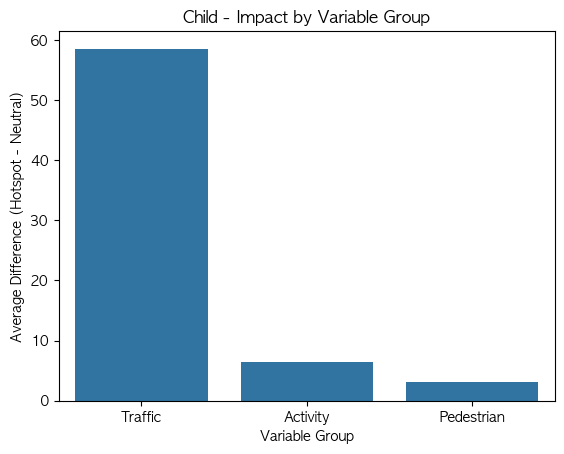

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x=child_group_summary.index,
    y=child_group_summary.values
)

plt.title("Child - Impact by Variable Group")
plt.xlabel("Variable Group")
plt.ylabel("Average Difference (Hotspot - Neutral)")

plt.show()

In [153]:
# 노인 hotspot vs non-hotspot 비교

gdf_elder.groupby("elder_hotspot")[cols].mean().round(2)

elder_compare = (
    gdf_elder
    .groupby("elder_hotspot")[cols]
    .mean()
    .T
)

elder_compare.round(2)

elder_hotspot,hotspot,neutral
resident_pop,12.31,2.12
flow_pop,12.18,1.38
working_pop,3.40,0.46
visit_pop,8.78,0.92
traffic_volume,393.39,129.47
mean_speed,25.30,10.56
congestion_freq,41.75,12.65
congestion_time,51.87,15.84
crosswalk_count,0.49,0.08
bus_stop_count,0.29,0.06


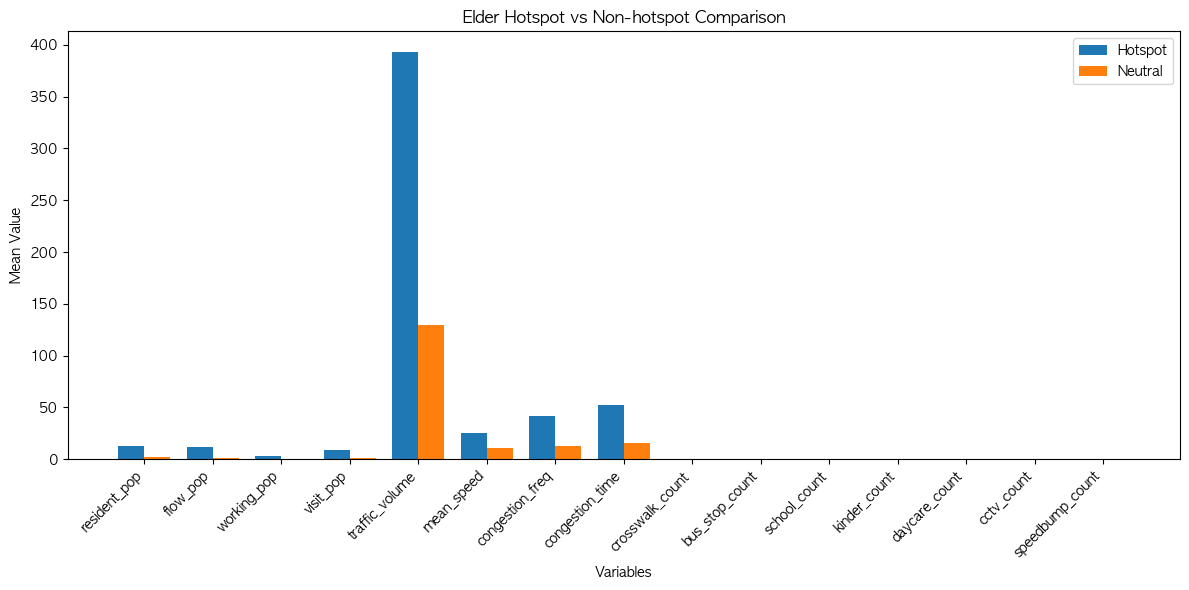

In [170]:
# Elder hotspot vs neutral comparison
df_plot = elder_compare.reset_index().rename(columns={"index": "variable"})

x = np.arange(len(df_plot))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df_plot["hotspot"], width=width, label="Hotspot")
plt.bar(x + width/2, df_plot["neutral"], width=width, label="Neutral")

plt.xticks(x, df_plot["variable"], rotation=45, ha="right")
plt.title("Elder Hotspot vs Non-hotspot Comparison")
plt.xlabel("Variables")
plt.ylabel("Mean Value")
plt.legend()
plt.tight_layout()
plt.show()

In [157]:
elder_compare["diff"] = elder_compare["hotspot"] - elder_compare["neutral"]
elder_compare.sort_values("diff", ascending=False)

elder_hotspot,hotspot,neutral,group,diff
traffic_volume,393.386405,129.474142,Traffic,263.912263
congestion_time,51.867173,15.837619,Traffic,36.029554
congestion_freq,41.748487,12.652848,Traffic,29.095639
mean_speed,25.304440,10.559787,Traffic,14.744653
flow_pop,12.183510,1.380339,Activity,10.803170
resident_pop,12.310485,2.120494,Pedestrian,10.189991
visit_pop,8.783914,0.921846,Activity,7.862068
working_pop,3.399596,0.458494,Activity,2.941102
crosswalk_count,0.485465,0.082182,Pedestrian,0.403284
bus_stop_count,0.288848,0.055095,Pedestrian,0.233752


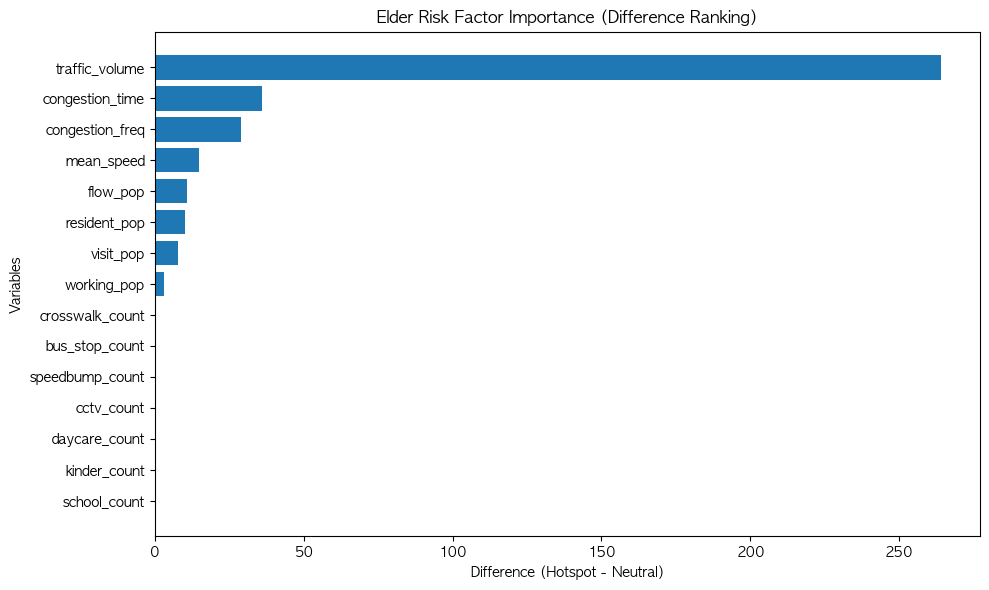

In [171]:
# Elder diff ranking
df_diff = elder_compare.sort_values("diff", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_diff.index, df_diff["diff"])

plt.title("Elder Risk Factor Importance (Difference Ranking)")
plt.xlabel("Difference (Hotspot - Neutral)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [133]:
# 통계 검정

results = []

for col in cols:

    hot = gdf_hotspot[gdf_hotspot["elder_hotspot"] == "hotspot"][col]
    neutral = gdf_hotspot[gdf_hotspot["elder_hotspot"] == "neutral"][col]

    stat, p = mannwhitneyu(hot, neutral)

    results.append({
        "variable": col,
        "hotspot_mean": hot.mean(),
        "neutral_mean": neutral.mean(),
        "p_value": p
    })

elder_test = pd.DataFrame(results).sort_values("p_value")

elder_test

,variable,hotspot_mean,neutral_mean,p_value
1,flow_pop,12.183510,1.380339,0.000000e+00
2,working_pop,3.399596,0.458494,0.000000e+00
3,visit_pop,8.783914,0.921846,0.000000e+00
4,traffic_volume,393.386405,129.474142,0.000000e+00
5,mean_speed,25.304440,10.559787,0.000000e+00
6,congestion_freq,41.748487,12.652848,0.000000e+00
7,congestion_time,51.867173,15.837619,0.000000e+00
8,crosswalk_count,0.485465,0.082182,0.000000e+00
9,bus_stop_count,0.288848,0.055095,0.000000e+00
0,resident_pop,12.310485,2.120494,1.327712e-193


- 노인 사고는 
    - 교통량이 많고
    - 혼잡도가 높고
    - 속도가 상대적으로 높은 곳
- 에서 많이 발생함

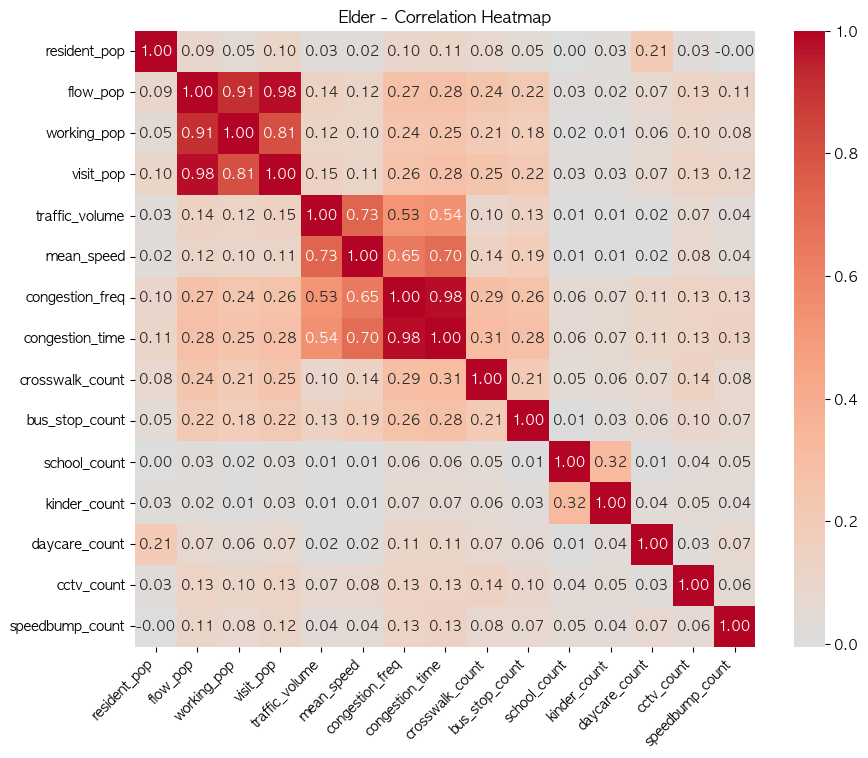

In [149]:
# 상관관계 히트맵

plt.figure(figsize=(10,8))
sns.heatmap(
    gdf_hotspot[cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
)

plt.title("Elder - Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [159]:
# variable groups
traffic_vars = ["traffic_volume", "mean_speed", "congestion_time", "congestion_freq"]
activity_vars = ["flow_pop", "visit_pop", "working_pop"]
pedestrian_vars = ["crosswalk_count", "school_count"]

# create group column
elder_compare["group"] = elder_compare.index.map(
    lambda x: "Traffic" if x in traffic_vars else
              "Activity" if x in activity_vars else
              "Pedestrian"
)

# group-wise mean diff
elder_group_summary = (
    elder_compare
    .groupby("group")["diff"]
    .mean()
    .sort_values(ascending=False)
)

elder_group_summary

group
Traffic       85.945527
Activity       7.202114
Pedestrian     1.383034
Name: diff, dtype: float64

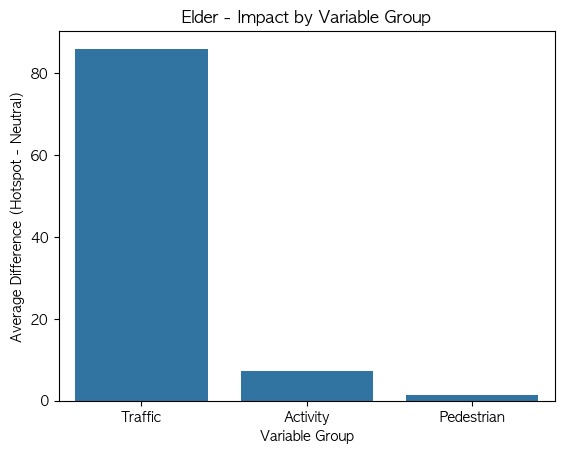

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=elder_group_summary.index, y=elder_group_summary.values)

plt.title("Elder - Impact by Variable Group")
plt.xlabel("Variable Group")
plt.ylabel("Average Difference (Hotspot - Neutral)")
plt.show()

In [134]:
accident.head()

,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,...,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,geometry,acc_hour,time_band
0,2024,1,주중,19시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,...,이륜,경상,41-50세,0,0,1,0,POINT (967805 1931238),19,17-20
1,2024,1,주중,07시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,...,이륜,부상신고,41-50세,0,0,0,1,POINT (966349 1927868),7,06-09
2,2024,1,주중,10시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,맑음,...,승용,상해없음,51-60세,0,1,0,0,POINT (967987 1934555),10,10-16
3,2024,1,주중,17시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,맑음,...,승용,중상,31-40세,0,1,0,0,POINT (964623 1933493),17,17-20
4,2024,1,주중,23시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,맑음,...,승용,경상,31-40세,0,0,1,0,POINT (964980 1933861),23,21-23


취약계층 사고 핫스팟에서 주로 발생한 사고 종류 먼지 파악....